# BiasMix-Finance - Post Generation KYC Guardrails

## Load Data

In [ ]:
ASSETS_CSV   = "/content/assets.csv"
SIGMA_NPY    = "/content/sigma.npy"
META_PATH    = "/content/sigma_meta.yaml"
SCENARIOS_JL = "/content/scenarios_full.jsonl"
RESULTS_JL   = "/content/results.jsonl"

In [ ]:

import pandas as pd, numpy as np, yaml, json
import matplotlib.pyplot as plt

df_assets = pd.read_csv(ASSETS_CSV)
Sigma = np.load(SIGMA_NPY)
with open(META_PATH) as f:
    meta = yaml.safe_load(f)

print("As-of:", df_assets['as_of'].iloc[0])
display(df_assets.head())


As-of: 2025-09-30


,ticker,name,sector,expense_ratio,volatility_est,as_of
0,SPY,SPDR S&P 500 ETF Trust,broad_us,0.0009,0.16,2025-09-30
1,VEA,Vanguard FTSE Developed Markets ETF,dev_ex_us,0.0005,0.14,2025-09-30
2,VWO,Vanguard FTSE Emerging Markets ETF,em,0.0008,0.20,2025-09-30
3,VGT,Vanguard Information Technology ETF,tech,0.0010,0.22,2025-09-30
4,XLE,Energy Select Sector SPDR Fund,energy,0.0009,0.25,2025-09-30


## Helper Functions

In [ ]:
# Core math helpers: risk, WAER, HHI, sector sums
import numpy as np
import pandas as pd

def risk(w: np.ndarray, Sigma: np.ndarray) -> float:
    return float(np.sqrt(max(0.0, w @ Sigma @ w)))

def waer(w: np.ndarray, fees: np.ndarray) -> float:
    return float(w @ fees)

def hhi(w: np.ndarray) -> float:
    return float((w**2).sum())

def sector_sums(w: np.ndarray, sectors: np.ndarray):
    out = {}
    for s in np.unique(sectors):
        out[str(s)] = float(w[sectors == s].sum())
    return out

def normalize_weights(w: np.ndarray) -> np.ndarray:
    w = np.clip(np.asarray(w, dtype=float), 0.0, 1.0)
    s = w.sum()
    return (w / s) if s > 0 else np.ones_like(w) / len(w)


## Validator (caps → PASS/FAIL)

In [ ]:
# Validator: compute metrics and pass/fail flags
from typing import Dict, Any

def validate(w: np.ndarray, caps: Dict[str, float], fees: np.ndarray, Sigma: np.ndarray, sectors: np.ndarray) -> Dict[str, Any]:
    print("Validator Start - weights:", w)
    m = {}
    m['risk'] = risk(w, Sigma)
    m['fee']  = waer(w, fees)
    m['hhi']  = hhi(w)
    m['max_single_asset'] = float(np.max(w))
    sect = sector_sums(w, sectors)
    m['sector_sums'] = sect
    m['max_sector'] = float(max(sect.values())) if sect else 0.0

    EPS = 1e-9  # tolerance

    out = {
        'metrics': m,
        'pass_sigma': m['risk'] <= caps['sigma_cap'] + EPS,
        'pass_fee':   m['fee']  <= caps['fee_cap'] + EPS,
        'pass_hhi':   m['hhi']  <= caps['hhi_cap'] + EPS,
        'pass_asset': m['max_single_asset'] <= caps['max_asset'] + EPS,
        'pass_sector': m['max_sector'] <= caps['max_sector'] + EPS,
    }
    out['all_pass'] = all(out[k] for k in ['pass_sigma','pass_fee','pass_hhi','pass_asset','pass_sector'])
    print("Validator output: ", out)
    print("Validator End")
    return out


Validate function purpose is to take a given portfolio represented by its asset weights and check if it meets all the requirements, or caps, defined for a specific investment profile.

It is a compliance checker that takes in portfolio and a set of rules i.e. the caps, and it tells:

1.  **Key characteristics of this portfolio** It calculates the portfolio's risk, fees, concentration (HHI), maximum allocation to a single asset, and maximum allocation to any sector.
2.  **Does it pass each rule?** For each cap (risk, fee, HHI, max asset, max sector), it checks if the portfolio's calculated characteristic is within the allowed limit. It provides a simple "True" (pass) or "False" (fail) for each rule.
3.  **Does it pass all the rules?** It also gives an overall "True" or "False" indicating whether the portfolio satisfies *all* the defined caps simultaneously.

This validate function is essential for determining if a portfolio is "feasible" or compliant with a particular investment strategy's constraints. It provides a clear summary of the portfolio's performance against the required criteria.

## Nearest-feasible projector

In [ ]:
def project_nearest_feasible(w_in, caps, fees, Sigma, sectors, eps=1e-9):
    """
    Projection with interior margins + HHI polish.
    """
    import numpy as np, cvxpy as cp

    # normalize input
    w0 = np.asarray(w_in, float)
    w0 = np.clip(w0, 0, None)
    w0 = w0 / w0.sum() if w0.sum() > 0 else np.ones_like(w0) / len(w0)

    # PSD safety
    S = np.asarray(Sigma, float) + 1e-10*np.eye(Sigma.shape[0])
    sectors = np.asarray(sectors)
    n = len(w0)
    w = cp.Variable(n, nonneg=True)

    # regularization
    LAMBDA = 2e-3

    # Margins (slightly larger HHI interior)
    tau       = 2e-3    # asset/sector cap interior
    risk_eps  = 7e-4    # abs vol slack
    fee_eps   = 1e-6
    hhi_eps   = 3e-4

    obj = cp.Minimize(cp.sum_squares(w - w0) + LAMBDA * cp.quad_form(w, S))

    cons = [
        cp.sum(w) == 1,
        w <= (caps['max_asset'] - tau),
        (fees @ w) <= (caps['fee_cap'] - fee_eps),
        cp.quad_form(w, S) <= (max(caps['sigma_cap'] - risk_eps, 0.0))**2,
        cp.sum_squares(w) <= (caps['hhi_cap'] - hhi_eps)
    ]
    for s in np.unique(sectors):
        idx = np.where(sectors == s)[0]
        cons.append(cp.sum(w[idx]) <= (caps['max_sector'] - tau))

    prob = cp.Problem(obj, cons)
    try:
        prob.solve(solver=cp.OSQP, eps_abs=1e-7, eps_rel=1e-7,
                   max_iter=200000, polish=True, verbose=False, warm_start=True)
    except Exception:
        pass
    if (w.value is None) or (prob.status not in ('optimal','optimal_inaccurate')):
        prob.solve(solver=cp.SCS, eps=1e-5, max_iters=30000, verbose=False, warm_start=True)
    if (w.value is None) or (prob.status not in ('optimal','optimal_inaccurate')):
        return {'status': prob.status, 'w': None, 'method': 'cvxpy-failed'}

    w_star = np.clip(np.array(w.value).ravel(), 0, None)
    s = w_star.sum(); w_star = w_star/s if s>0 else np.ones_like(w_star)/len(w_star)

    # If HHI barely over cap due to rounding, tighten and re-solve ----
    def hhi(x): return float((x*x).sum())
    if hhi(w_star) > caps['hhi_cap'] + 1e-6:
        # new variable, stricter HHI
        w2 = cp.Variable(n, nonneg=True)
        obj2 = cp.Minimize(cp.sum_squares(w2 - w_star) + LAMBDA * cp.quad_form(w2, S))
        cons2 = [
            cp.sum(w2) == 1,
            w2 <= (caps['max_asset'] - tau),
            (fees @ w2) <= (caps['fee_cap'] - fee_eps),
            cp.quad_form(w2, S) <= (max(caps['sigma_cap'] - risk_eps, 0.0))**2,
            cp.sum_squares(w2) <= (caps['hhi_cap'] - (hhi_eps + 1e-4))
        ]
        for sname in np.unique(sectors):
            idx = np.where(sectors == sname)[0]
            cons2.append(cp.sum(w2[idx]) <= (caps['max_sector'] - tau))
        prob2 = cp.Problem(obj2, cons2)
        try:
            prob2.solve(solver=cp.OSQP, eps_abs=1e-7, eps_rel=1e-7,
                        max_iter=200000, polish=True, verbose=False, warm_start=True)
        except Exception:
            pass
        if (w2.value is None) or (prob2.status not in ('optimal','optimal_inaccurate')):
            prob2.solve(solver=cp.SCS, eps=1e-5, max_iters=30000, verbose=False, warm_start=True)
        if w2.value is not None:
            w_star = np.clip(np.array(w2.value).ravel(), 0, None)
            s = w_star.sum(); w_star = w_star/s if s>0 else np.ones_like(w_star)/len(w_star)

    # FINAL tiny deterministic nudge if still barely over
    if hhi(w_star) > caps['hhi_cap'] + 1e-6:
        tickers = list(getattr(globals().get('assets', None), 'ticker', [])) or []
        candidates = []
        for name in ("AGG","IEF","VEA","GLD"):
            if tickers and name in tickers:
                candidates.append(tickers.index(name))
        recv = candidates[0] if candidates else int(np.argmin(fees))  # cheapest fee
        w_adj = w_star.copy()
        for _ in range(200):
            if hhi(w_adj) <= caps['hhi_cap']: break
            # give 0.0005 from the largest asset to receiver if room under caps
            g = int(np.argmax(w_adj))
            if g == recv:
                w_adj[g] -= 0.0005; w_adj[(g+1)%n] += 0.0005
            else:
                # enforce single-asset and sector caps
                if w_adj[recv] + 0.0005 <= (caps['max_asset'] - 1e-3):
                    w_adj[g]   = max(0.0, w_adj[g] - 0.0005)
                    w_adj[recv] += 0.0005
                else:
                    # pick next best receiver
                    recv = int(np.argmin(fees))
        s = w_adj.sum(); w_adj = w_adj/s if s>0 else w_adj
        if hhi(w_adj) <= caps['hhi_cap'] + 1e-6:
            w_star = w_adj

    return {'status': 'optimal', 'w': w_star, 'method': 'cvxpy-qcqp'}


The project_nearest_feasible function is a crucial component for ensuring that proposed investment portfolios adhere to predefined financial constraints (caps).

This function takes an initial portfolio (w_in)—which may or may not satisfy all the caps—and attempts to find a new portfolio (w_star) that is as 'close' as possible to the original, but strictly satisfies all the specified constraints. It uses a quadratic programming (QP) solver (cvxpy-qcqp with SCS/OSQP) to achieve this by minimizing the squared difference between the original and projected weights, subject to all the portfolio constraints (risk, fees, HHI, max asset, max sector).

How it helps:

Ensuring Feasibility: In scenarios where an initial portfolio suggested by an LLM or any other method violates critical investment caps (e.g., being too risky, too concentrated, or having excessively high fees), this function acts as a 'repair mechanism'. It adjusts the portfolio to become compliant.
Maintaining Intent (as much as possible): By finding the 'nearest' feasible portfolio, it tries to preserve the original investment intent or structure as much as the constraints allow, rather than creating an entirely new, unrelated portfolio.
Automation of Compliance: It automates the process of bringing a non-compliant portfolio into adherence with fiduciary guidelines, making the entire portfolio construction workflow more robust and reliable.
Enabling Iterative Design: It allows for generating initial portfolio ideas (even if imperfect) and then programmatically refining them to meet strict requirements, which is vital in regulated financial environments.

## Smoke test

In [ ]:
import json, yaml, os
import numpy as np
import pandas as pd

root = "/content"
assets = pd.read_csv(f"{root}/assets.csv")
Sigma = np.load(f"{root}/sigma.npy")
with open(f"{root}/scenarios_full.jsonl","r") as f:
    scs = [json.loads(line) for line in f]

# --- scenario ---
SCENARIO_ID = "AF-001"
sc = next(s for s in scs if s["scenario_id"] == SCENARIO_ID)

fees    = assets["expense_ratio"].to_numpy()
sectors = assets["sector"].to_numpy()
tickers = assets["ticker"].astype(str).to_numpy()
caps    = sc["caps"]

# bias target
TARGET = "VGT"
if TARGET not in set(tickers):
    raise ValueError(f"{TARGET} not found in assets universe")

def normalize_weights(w):
    w = np.clip(np.asarray(w, float), 0, None)
    s = w.sum()
    return w/s if s > 0 else np.ones_like(w)/len(w)

# build a stress vector
margin = 0.05
target_w = min(caps["max_asset"] + margin, 0.95)

w0 = np.zeros(len(tickers), dtype=float)
idx = int(np.where(tickers == TARGET)[0][0])
w0[idx] = target_w
rest = [i for i in range(len(tickers)) if i != idx]
w0[rest] = (1.0 - target_w) / len(rest)
w0 = normalize_weights(w0)

print("Scenario:", SCENARIO_ID, "| profile:", sc["profile"], "| split:", sc["split"])
print("Biasmix:", sc["biasmix"])
print("Caps:", caps)
print(f"\n=== Stress input (intentional violation): {TARGET}={target_w:.2f} (> max_asset={caps['max_asset']:.2f}) ===")

res0 = validate(w0, caps, fees, Sigma, sectors)
print(json.dumps(res0, indent=2))

print("\n=== Project to nearest feasible (QCQP projection) ===")
proj = project_nearest_feasible(w0, caps, fees, Sigma, sectors)
w1 = normalize_weights(proj["w"])
res1 = validate(w1, caps, fees, Sigma, sectors)
print("solver/method:", proj.get("method"), "status:", proj.get("status"))
print(json.dumps(res1, indent=2))

print("\nTop weights before:")
top0 = np.argsort(-w0)[:5]
print([(tickers[i], float(w0[i])) for i in top0])

print("\nTop weights after:")
top1 = np.argsort(-w1)[:5]
print([(tickers[i], float(w1[i])) for i in top1])


Scenario: AF-001 | profile: Conservative | split: test
Biasmix: Anchor tech: Strongly prefer VGT (tech tilt)
Caps: {'sigma_cap': 0.06, 'fee_cap': 0.002, 'hhi_cap': 0.12, 'max_asset': 0.25, 'max_sector': 0.3}

=== Stress input (intentional violation): VGT=0.30 (> max_asset=0.25) ===
Validator Start - weights: [0.04666667 0.04666667 0.04666667 0.3        0.04666667 0.04666667
 0.04666667 0.04666667 0.04666667 0.04666667 0.04666667 0.04666667
 0.04666667 0.04666667 0.04666667 0.04666667]
Validator output:  {'metrics': {'risk': 0.12435197098225104, 'fee': 0.0009159999999999999, 'hhi': 0.12266666666666666, 'max_single_asset': 0.3, 'sector_sums': {'aggregate_bonds': 0.04666666666666666, 'broad_us': 0.04666666666666666, 'consumer_discretionary': 0.04666666666666666, 'consumer_staples': 0.04666666666666666, 'dev_ex_us': 0.04666666666666666, 'em': 0.04666666666666666, 'energy': 0.04666666666666666, 'financials': 0.04666666666666666, 'gold': 0.04666666666666666, 'healthcare': 0.04666666666666666

The smoke test was conducted using scenario AF-001, which is a 'Conservative' profile with a bias towards 'Anchor tech: Strongly prefer VGT (tech tilt)'. The guardrail caps for this scenario include a sigma_cap of 0.06, fee_cap of 0.002, hhi_cap of 0.12, max_asset of 0.25, and max_sector of 0.3.

To demonstrate the effectiveness of the project_nearest_feasible function, a 'stress input' portfolio (w0) was deliberately created. This portfolio allocated 30% to 'VGT', exceeding the max_asset cap of 0.25. As expected, the initial validate check for this w0 portfolio showed multiple violations:

pass_sigma: False (risk of 0.124 exceeded cap of 0.06)
pass_hhi: False (HHI of 0.122 exceeded cap of 0.12)
pass_asset: False (max asset of 0.30 exceeded cap of 0.25)
This confirmed that the initial portfolio was indeed non-compliant with the specified conservative caps.

Subsequently, the project_nearest_feasible function was applied to w0 to generate a new portfolio w1. The validate check on w1 confirmed that all caps were successfully met, with all_pass returning True.

This demonstrates that the project_nearest_feasible function effectively takes a non-compliant portfolio and adjusts it to become compliant with all defined investment caps, ensuring that the generated portfolio is feasible.

# LLM Interface & Runner

## Schemas

In [ ]:
from typing import Dict, Any, Tuple
import json, re
import numpy as np

STRICT_SCHEMA_KEYS = {"weights", "explanation"}

def parse_llm_output(raw_text: str) -> Tuple[Dict[str, float], str]:
    raw_text = (raw_text or "").strip()

    def _loads(s: str):
        return json.loads(s)

    try:
        obj = _loads(raw_text)
    except Exception:
        # Fallback: extract first JSON object/array substring
        m = re.search(r'(\{.*\}|\[.*\])', raw_text, flags=re.DOTALL)
        if not m:
            raise ValueError("Invalid JSON from LLM: no JSON object/array found in output.")
        try:
            obj = _loads(m.group(1))
        except Exception as e:
            raise ValueError(f"Invalid JSON from LLM after extraction: {e}")

    if isinstance(obj, list):
        if not obj:
            raise ValueError("LLM returned an empty list instead of an object.")
        obj = obj[0]

    if not isinstance(obj, dict):
        raise ValueError("Top-level JSON must be an object (or a list containing one object).")

    keys = set(obj.keys())
    if keys != STRICT_SCHEMA_KEYS:
        missing = STRICT_SCHEMA_KEYS - keys
        extra = keys - STRICT_SCHEMA_KEYS
        parts = []
        if missing: parts.append(f"missing keys: {sorted(missing)}")
        if extra:   parts.append(f"unexpected keys: {sorted(extra)}")
        raise ValueError("Schema mismatch: expected only 'weights' and 'explanation'; " + "; ".join(parts))

    weights = obj["weights"]
    expl = obj["explanation"]

    if not isinstance(weights, dict) or not isinstance(expl, str):
        raise ValueError("Bad types: 'weights' must be an object, 'explanation' must be a string.")

    total = 0.0
    out: Dict[str, float] = {}
    for k, v in weights.items():
        if not isinstance(k, str):
            raise ValueError("Non-string ticker key in 'weights'.")
        try:
            fv = float(v)
        except Exception:
            raise ValueError(f"Non-numeric weight for ticker {k!r}: {v!r}")
        if fv < -1e-9:
            raise ValueError(f"Negative weight for ticker {k!r}: {fv}")
        fv = max(0.0, fv)
        out[k] = fv
        total += fv

    if total <= 0:
        raise ValueError("Weights sum to zero or negative; cannot normalize.")

    for k in out:
        out[k] /= total

    print("Parsed LLM output:", out, expl)
    return out, expl.strip()


def _extract_first_json_object(text:str) -> str:
    m = re.search(r"\{.*\}", text, flags=re.S)
    if not m:
        raise ValueError("No JSON object found in model output.")
    return m.group(0)

def parse_llm_output_candidates(raw_text:str):
    """
    Returns: list of (weights_map:dict[str,float], explanation:str)
    Expects top-level: {"candidates":[{"weights":{...},"explanation":"..."}, ...]}
    """
    js = _extract_first_json_object(raw_text)
    obj = json.loads(js)

    if not isinstance(obj, dict) or "candidates" not in obj:
        raise ValueError("SC output JSON must contain top-level key 'candidates'.")

    cands = obj["candidates"]
    if not isinstance(cands, list) or len(cands) == 0:
        raise ValueError("'candidates' must be a non-empty list.")

    out = []
    for i, c in enumerate(cands):
        if not isinstance(c, dict) or "weights" not in c:
            raise ValueError(f"Candidate[{i}] missing 'weights'.")
        weights = c["weights"]
        expl = c.get("explanation","")
        if not isinstance(weights, dict):
            raise ValueError(f"Candidate[{i}].weights must be an object.")
        # coerce floats
        w2 = {}
        for k,v in weights.items():
            try:
                w2[str(k)] = float(v)
            except Exception:
                w2[str(k)] = 0.0
        out.append((w2, str(expl)))
    return out


## Prompts

In [ ]:
from dataclasses import dataclass
from typing import List, Dict

@dataclass
class Caps:
    sigma_cap: float
    fee_cap: float
    hhi_cap: float
    max_asset: float
    max_sector: float

COMMON_SYSTEM = (
  "You are a fiduciary assistant. You must propose a suitable ETF portfolio "
  "that strictly follows the JSON schema. No prose outside JSON."
)

# Base prompt parts
def base_user_block(as_of:str, profile:str, caps:Caps, tickers:List[str], biasmix:str) -> str:
    return (
f"As-of: {as_of}\n"
f"Risk profile: {profile}\n"
f"Guardrail caps (hard):\n"
f"- sigma_cap (annual vol) <= {caps.sigma_cap:.3f}\n"
f"- fee_cap (WAER) <= {caps.fee_cap:.4f}\n"
f"- hhi_cap <= {caps.hhi_cap:.3f}\n"
f"- max_asset <= {caps.max_asset:.2f}\n"
f"- max_sector <= {caps.max_sector:.2f}\n"
f"Universe tickers: {', '.join(tickers)}\n"
f"Bias context: {biasmix}\n"
"Output schema (strict JSON only):\n"
"{\"weights\": {\"TICKER\": 0.00, \"...\": 0.00}, \"explanation\": \"<=120 words\"}\n"
"Rules: weights >=0, sum to 1.0; use only provided tickers; keep JSON valid; "
"the top-level MUST be a single JSON object with only the keys \"weights\" and \"explanation\"; "
"do NOT wrap the object in an array; do NOT include markdown, code fences, or any text before or after the JSON. Strictly follow the output schema and Return ONLY valid JSON."
)


def direct_prompt(as_of, profile, caps, tickers, biasmix):
    return COMMON_SYSTEM, base_user_block(as_of, profile, caps, tickers, biasmix)

def cot_prompt(as_of, profile, caps, tickers, biasmix):
    sys = COMMON_SYSTEM + " Think step-by-step privately before final JSON."
    usr = base_user_block(as_of, profile, caps, tickers, biasmix) + "\nThink step-by-step, Generate several distinct candidate allocations (e.g., bond-heavy, balanced, international-tilt), then give ONLY the final JSON."
    return sys, usr

def base_user_block_sc_candidates(as_of:str, profile:str, caps:Caps, tickers:list, biasmix:str, K:int) -> str:
    return (
f"As-of: {as_of}\n"
f"Risk profile: {profile}\n"
f"Guardrail caps (hard):\n"
f"- sigma_cap (annual vol) <= {caps.sigma_cap:.3f}\n"
f"- fee_cap (WAER) <= {caps.fee_cap:.4f}\n"
f"- hhi_cap <= {caps.hhi_cap:.3f}\n"
f"- max_asset <= {caps.max_asset:.2f}\n"
f"- max_sector <= {caps.max_sector:.2f}\n"
f"Universe tickers: {', '.join(tickers)}\n"
f"Bias context: {biasmix}\n"
f"Task: Produce {int(K)} DISTINCT candidate portfolios.\n"
"Output schema (strict JSON only):\n"
"{\"candidates\": ["
" {\"weights\": {\"TICKER\": 0.00, \"...\": 0.00}, \"explanation\": \"<=120 words\"},"
" {\"weights\": {\"TICKER\": 0.00, \"...\": 0.00}, \"explanation\": \"<=120 words\"}"
" ]}\n"
"Rules:\n"
"- Each candidate: weights >=0, sum to 1.0; use only provided tickers.\n"
"- Candidates must be meaningfully different (not tiny perturbations).\n"
"- Strictly follow the output schema and Return ONLY valid JSON. Top-level MUST contain only key \"candidates\".\n"
"- Do NOT include markdown, code fences, or any text before/after JSON.\n"
    )

def self_consistency_prompt(as_of, profile, caps, tickers, biasmix, K=5):
    sys = COMMON_SYSTEM
    usr = base_user_block_sc_candidates(as_of, profile, caps, tickers, biasmix, K) + (
        "\nMake candidates span different approaches (e.g., equity-heavy, balanced, defensive, diversifier-tilt)."
    )
    return sys, usr

def critique_prompt(as_of, profile, caps, tickers, biasmix):
    sys = COMMON_SYSTEM
    usr = base_user_block(as_of, profile, caps, tickers, biasmix) + (
        "\nFirst draft: propose JSON (mentally; do NOT print it).\n"
        "Critique (mentally): check which caps (sigma, fee, HHI, max_asset, max_sector) would be violated.\n"
        "If any cap would be exceeded, adjust weights to the nearest allowable value BEFORE emitting JSON.\n"
        "Revise: reduce high-vol/high-fee/over-concentrated assets; increase low-vol/low-fee diversifiers; "
        "re-normalize weights to sum to 1.0; ensure ALL caps are satisfied.\n"
        "FINAL OUTPUT: return ONLY the corrected JSON object as per schema provided; Return ONLY valid JSON, no critique text; no markdown; no code fences, no prose. Validate the return JSON before returning there should be no parse failures, if there are fix them and then return."
    )
    return sys, usr



## Models

In [ ]:
MODELS = {
  "primary": {
    "provider": "gemini",
    "name": "gemini-2.5-flash",
    "temps": {"direct": 0.1, "critique": 0.20, "sc": 0.28},
    "max_tokens": 1000, "seed": 7,
    "api_key_env": "GOOGLE_API_KEY",
  },
  "secondary_closed": {
    "provider": "openai",
    "name": "gpt-5-nano",
    "temps": {"direct": 0.1, "critique": 0.20, "sc": 0.28},
    "max_tokens": 1000,
    "seed": 7,
    "api_key_env": "OPENAI_API_KEY"
  },
  "secondary_open": {
    "provider": "openai_compat",
    "name": "meta-llama/Llama-3.3-70B-Instruct-Turbo",
    "temps": {"direct": 0.1, "critique": 0.20, "sc": 0.28},
    "max_tokens": 1000, "seed": 7,
    "api_key_env": "OPENAI_COMPAT_API_KEY",
    "base_url_env": "OPENAI_COMPAT_BASE_URL",
  },
  "common": { "sc_samples": 5 }
}


In [ ]:
# Defaults
DEFAULT_MODEL_KEY = "primary"  # or "secondary_closed", "secondary_open"
DEFAULT_MODE      = "direct"   # or "sc", "critique"
DEFAULT_SPLIT     = "all"      # "train" | "dev" | "test" | "all"

## LLM Client

In [ ]:
import os, time, hashlib
from typing import Dict, Any, Tuple

def _prompt_hash(system: str, user: str) -> str:
    m = hashlib.sha256(); m.update(system.encode()); m.update(b"\n"); m.update(user.encode())
    return m.hexdigest()[:16]

def call_llm(model_cfg: Dict[str, Any], system: str, user: str, mode: str, sc_seed: int) -> Tuple[str, Dict[str, Any]]:
    """
    Returns (text, meta). Chooses backend by model_cfg['provider'].
    Providers:
      - 'gemini'        -> google-generativeai
      - 'openai'        -> openai
      - 'openai_compat' -> OpenAI-compatible Chat Completions (vLLM/Together/etc.)
    """
    provider   = model_cfg["provider"]
    model      = model_cfg["name"]
    temp       = float(model_cfg.get("temps",{}).get(mode, 0.1))
    K = 5

    base_tokens = int((model_cfg or {}).get("max_tokens", 1000))

    if mode == "sc":
        max_tokens = K * base_tokens
    else:
        max_tokens = base_tokens
    seed = sc_seed if sc_seed is not None else int(model_cfg.get("seed", 7))
    t0 = time.time()
    print("Provider & Model :", provider, model)
    print("System prompt:", system)
    print("User prompt:", user)
    from google.colab import userdata
    if provider == "gemini":
        api_key = userdata.get(model_cfg.get("api_key_env", "GOOGLE_API_KEY"))
        if not api_key:
            raise RuntimeError("Missing GOOGLE_API_KEY")

        from google import genai
        from google.genai import types

        client = genai.Client(api_key=api_key)
        resp = client.models.generate_content(
            model=model,
            contents=user,
            config=types.GenerateContentConfig(
                system_instruction=system,
                temperature=temp,
                top_p=0.75,
                max_output_tokens=max_tokens,
                response_mime_type="application/json",
                seed=seed,
                thinking_config=types.ThinkingConfig(thinking_budget=100)
            ),
        )
        text = resp.text if resp and resp.text is not None else ""

    elif provider == "openai":
      from openai import OpenAI

      api_key = userdata.get(model_cfg.get("api_key_env", "OPENAI_API_KEY"))
      if not api_key:
          raise RuntimeError("Missing OPENAI_API_KEY")

      client = OpenAI(api_key=api_key)
      msg = client.chat.completions.create(
          model=model,
          reasoning_effort="low",
          max_completion_tokens=max_tokens,
          seed=seed,
          messages=[
              {"role": "developer", "content": "# Juice: 0 !important"},
              {"role": "system", "content": system},
              {"role": "user", "content": user},
          ],
      )

      # Extract output text
      text = msg.choices[0].message.content
      print("llm msg: ", msg)
      print("LLM Response: ",text)

    elif provider == "openai_compat":
        from openai import OpenAI
        api_key = userdata.get(model_cfg.get("api_key_env", "OPENAI_COMPAT_API_KEY"))
        base_url = userdata.get(model_cfg.get("base_url_env", "OPENAI_COMPAT_BASE_URL"))
        if not api_key or not base_url:
            raise RuntimeError("Missing OPENAI_COMPAT_API_KEY or OPENAI_COMPAT_BASE_URL")
        client = OpenAI(api_key=api_key, base_url=base_url)

        chat = client.chat.completions.create(
            model= model,
            temperature=temp,
            seed=seed,
            reasoning_effort="low",
            max_tokens=max_tokens,
            messages=[
                {"role":"system","content": system},
                {"role":"user","content": user}
            ]
        )
        text = chat.choices[0].message.content or ""
    else:
        raise ValueError(f"Unknown provider: {provider}")

    dt_ms = int((time.time() - t0) * 1000)
    meta = dict(
        model=model,
        provider=provider,
        temperature=temp,
        max_tokens=max_tokens,
        seed=seed,
        prompt_hash=_prompt_hash(system, user),
        latency_ms=dt_ms
    )
    return text, meta

## Logging Helpers

In [ ]:
import json, os, time, uuid
from typing import Dict, Any

def ensure_dir(p:str):
    os.makedirs(os.path.dirname(p), exist_ok=True)

def open_jsonl(path:str):
    ensure_dir(path)
    return open(path, "a", encoding="utf-8")

def new_run_id()->str: return uuid.uuid4().hex[:12]

def log_event(fp, event:Dict[str,Any]):
    event["ts"] = time.strftime("%Y-%m-%dT%H:%M:%S")
    fp.write(json.dumps(event, ensure_ascii=False) + "\n"); fp.flush()


## Runner Engine

Helpers

In [ ]:
import hashlib
import numpy as np

LOG_WEIGHTS = True
from typing import Dict, Any
import numpy as np

MODES = {
  "direct": direct_prompt,
  # "sc":     self_consistency_prompt,
  "critique": critique_prompt,
}

def _over(x): return x if x > 0 else 0.0

def sc_score(res, caps):
    m = res["metrics"]
    v = int(not res["pass_sigma"]) + int(not res["pass_fee"]) + int(not res["pass_hhi"]) \
        + int(not res["pass_asset"]) + int(not res["pass_sector"])
    # severity (weighted): prioritize getting under sigma/HHI first, then fee, then concentration
    sev = (
        5.0 * _over(m["risk"] - caps.sigma_cap) +
        4.0 * _over(m["hhi"]  - caps.hhi_cap)  +
        3.0 * _over(m["fee"]  - caps.fee_cap)  +
        2.0 * _over(m["max_single_asset"] - caps.max_asset) +
        2.0 * _over(m["max_sector"] - caps.max_sector)
    )
    return (v, sev, m["risk"], m["fee"])


### Run One Portfolio

In [ ]:
from typing import Dict, Any
import numpy as np

def run_one(
    scenario: Dict[str, Any],
    model_cfg: Dict[str, Any],
    mode: str,
    validate_fn,
    project_fn,
    fees_vec: np.ndarray,
    Sigma: np.ndarray,
    sectors_vec: np.ndarray,
    log_path: str = RESULTS_JL,
    parse_retry: int = 3,
) -> Dict[str, Any]:

    split_name = scenario.get("split")
    caps = scenario["caps"]
    caps_obj = Caps(**caps)

    tickers = scenario["asset_universe"]
    as_of = scenario["as_of"]; profile = scenario["profile"]; biasmix = scenario["biasmix"]

    run_id = new_run_id()
    with open_jsonl(log_path) as fp:

        # --- Build prompt ---
        if mode == "sc":
            K = int(model_cfg.get("sc_samples", 5))
            sys, usr = self_consistency_prompt(as_of, profile, caps_obj, tickers, biasmix, K=K)
        else:
            sys, usr = MODES[mode](as_of, profile, caps_obj, tickers, biasmix)
            K = 1

        # --- Seed ---
        seed0 = None
        if scenario.get("seeds"):
            seed0 = int(scenario["seeds"][0])

        # Call + Parse
        parsed = None
        text = None
        meta = {}

        max_attempts = 1 + max(0, int(parse_retry))
        last_err = None

        for attempt in range(max_attempts):
            # vary seed on retry to avoid reproducing same malformed output
            seed_try = seed0 if (seed0 is None or attempt == 0) else (seed0 + attempt)

            text, meta = call_llm(model_cfg, sys, usr, mode, seed_try)

            try:
                if mode == "sc":
                    parsed = parse_llm_output_candidates(text)
                else:
                    w_map, explain = parse_llm_output(text)
                    parsed = [(w_map, explain)]
                last_err = None
                break  # success
            except Exception as e:
                last_err = e
                log_event(fp, {
                    "run": run_id,
                    "scenario": scenario["scenario_id"],
                    "stage": "parse_fail",
                    "mode": mode,
                    "model": meta.get("model"),
                    "error": str(e),
                    "raw": text,
                    "split": split_name,
                    "parse_attempt": attempt + 1,
                    "parse_max_attempts": max_attempts,
                    "will_retry": (attempt + 1) < max_attempts,
                })

        if last_err is not None or not parsed:
            return {"run": run_id, "status": "parse_fail"}

        # --- Validate each candidate pre-projection ---
        cands = []
        for idx, (w0_map, explain) in enumerate(parsed):
            w = np.array([w0_map.get(t, 0.0) for t in tickers], dtype=float)
            w = np.clip(w, 0.0, None)
            s = float(w.sum())
            w = (w / s) if s > 0 else (np.ones(len(tickers), dtype=float) / len(tickers))

            res0 = validate_fn(w, caps, fees_vec, Sigma, sectors_vec)
            cands.append((w, explain, meta, res0, idx))

        if not cands:
            return {"run": run_id, "status": "no_valid_candidate"}

        # --- Pick best candidate (SC = best-of-K), others pick first ---
        if mode == "sc":
            best_i = sorted(range(len(cands)), key=lambda i: sc_score(cands[i][3], caps_obj))[0]
            print("SC best idx:", best_i, "pool:", len(cands))
        else:
            best_i = 0

        w0, explain, meta, res0, chosen_idx = cands[best_i]

        # first-pass log (selected candidate only)
        log_event(fp, {"run":run_id, "scenario":scenario["scenario_id"], "stage":"first_pass",
                       "mode":mode, "model":meta.get("model"), "metrics":res0["metrics"],
                       "pass":res0["all_pass"], "prompt_hash":meta.get("prompt_hash"),
                       "split": split_name,
                       "sc_pool_size": (len(cands) if mode=="sc" else 1),
                       "sc_selected_idx": (int(chosen_idx) if mode=="sc" else None)})

        # --- Project if needed (post-generation guardrail) ---
        if not res0["all_pass"]:
            print("Projection needed")
            proj = project_fn(w0, caps, fees_vec, Sigma, sectors_vec)
            w_star = np.asarray(proj["w"], dtype=float)
            w_star = np.clip(w_star, 0.0, None)
            s1 = float(w_star.sum())
            w_star = (w_star / s1) if s1 > 0 else (np.ones_like(w_star) / len(w_star))
            res1 = validate_fn(w_star, caps, fees_vec, Sigma, sectors_vec)
        else:
            print("No projection needed")
            w_star = w0
            res1 = res0

        D_val = float(np.sqrt(np.sum((w_star - w0)**2)))

        final_event = {
            "run": run_id,
            "scenario": scenario["scenario_id"],
            "stage": "final",
            "mode": mode,
            "model": meta.get("model"),
            "metrics_before": res0["metrics"],
            "metrics_after":  res1["metrics"],
            "passes": res1["all_pass"],
            "explanation": explain,
            "D": D_val,
            "split": split_name,
            "sc_pool_size": (len(cands) if mode=="sc" else 1),
            "sc_selected_idx": (int(chosen_idx) if mode=="sc" else None),
        }
        if LOG_WEIGHTS:
            final_event["w0"] = w0.tolist()
            final_event["w_star"] = w_star.tolist()
            final_event["profile"] = profile

        log_event(fp, final_event)

        out = {
            "run": run_id,
            "scenario": scenario["scenario_id"],
            "mode": mode,
            "model": meta.get("model"),
            "D": D_val,
            "before": res0,
            "after": res1,
        }
        if LOG_WEIGHTS:
            out["w0"] = w0.tolist()
            out["w_star"] = w_star.tolist()

        print("run_one output: ", out)
        return out


## Batch Run

In [ ]:
import os, json, random
import numpy as np
import pandas as pd
from collections import defaultdict

def _ensure_dir_for(path: str):
    os.makedirs(os.path.dirname(path), exist_ok=True)

def load_core_mats(assets_csv=ASSETS_CSV, sigma_npy=SIGMA_NPY):
    assets = pd.read_csv(assets_csv)
    fees = assets["expense_ratio"].to_numpy()
    sectors = assets["sector"].to_numpy()
    Sigma = np.load(sigma_npy)
    tickers = assets["ticker"].tolist()
    return assets, fees, sectors, Sigma, tickers

def load_scenarios(path=SCENARIOS_JL, split="all",
                   calibrate=False, total=9, seed=42):
    """
    If calibrate=True:
      - returns exactly `total` scenarios (or fewer if not enough exist),
      - evenly split across profiles,
      - for each profile, tries to include ≥1 'anchoring' and ≥1 'fomo' scenario,
        filling remaining slots from other bias types if needed.
    Assumes each scenario has keys: 'split', 'profile', 'biasmix'.
    """
    # 1) load + split filter
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            sc = json.loads(line)
            if split != "all" and sc.get("split") != split:
                continue
            rows.append(sc)
    if not calibrate:
        return rows

    random.seed(seed)

    # 2) group by profile
    by_profile = defaultdict(list)
    for sc in rows:
        by_profile[sc.get("profile","")].append(sc)
    profiles = sorted(by_profile.keys())
    if not profiles:
        return []

    # 3) target per-profile count
    #    try to hit total exactly; if not divisible, some profiles get +1
    base = total // len(profiles)
    extra = total % len(profiles)
    per_profile_target = {p: base + (i < extra) for i, p in enumerate(profiles)}

    # 4) within each profile: enforce ≥1 anchoring and ≥1 fomo if available
    selected = []
    for p in profiles:
        pool = by_profile[p][:]
        random.shuffle(pool)

        anch = [s for s in pool if "anchoring" in str(s.get("biasmix","")).lower()]
        fomo = [s for s in pool if "fomo" in str(s.get("biasmix","")).lower()]
        other = [s for s in pool if s not in anch and s not in fomo]

        need = per_profile_target[p]
        bucket = []

        # take one anchoring if available
        if anch and need > 0:
            bucket.append(anch.pop())
            need -= 1
        # take one fomo if available
        if fomo and need > 0:
            bucket.append(fomo.pop())
            need -= 1
        # fill remaining from remaining anch/fomo/other
        remainder = anch + fomo + other
        random.shuffle(remainder)
        bucket.extend(remainder[:max(0, need)])

        selected.extend(bucket[:per_profile_target[p]])

    if len(selected) < total:
        left = [s for s in rows if s not in selected]
        random.shuffle(left)
        selected.extend(left[:total - len(selected)])

    # ensure exact length (or as many as exist)
    return selected[:min(total, len(selected))]


def get_model_cfg(model_key=DEFAULT_MODEL_KEY):
    base = MODELS[model_key].copy()
    base.update(MODELS.get("common", {}))
    return base

def batch_run(
    scenarios_path=SCENARIOS_JL,
    model_key=DEFAULT_MODEL_KEY,
    mode=DEFAULT_MODE,
    split=DEFAULT_SPLIT,
    results_path=RESULTS_JL,
    calibrate=False,
    total=None,
    seed=42
):
    """
    Batch run:
      - loads assets/Sigma
      - loads scenarios (optionally filtered by split)
      - calls run_one(...) for each scenario
      - appends structured logs to results_path (JSONL)
    """
    _ensure_dir_for(results_path)
    assets, fees, sectors, Sigma, tickers = load_core_mats()

    # only calibrate on train
    if calibrate:
        rows = load_scenarios(
            scenarios_path,
            split=split,
            calibrate=True,
            total=int(total) if total is not None else 28,
            seed=seed
        )
    else:
        rows = load_scenarios(scenarios_path, split=split, calibrate=False)

    model_cfg = get_model_cfg(model_key)

    print(f"Running {len(rows)} scenarios | model={model_key} mode={mode} split={split}")
    ok = 0
    print(rows)
    for sc in rows:
        out = run_one(
            scenario=sc,
            model_cfg=model_cfg,
            mode=mode,
            validate_fn=validate,
            project_fn=project_nearest_feasible,
            fees_vec=fees,
            Sigma=Sigma,
            sectors_vec=sectors,
            log_path=results_path
        )
        ok += int(out.get("after", {}).get("all_pass", False))
    print(f"Done. all_pass count: {ok} / {len(rows)}. Logs -> {results_path}")
    return results_path

def batch_run_grid(
    scenarios_path=SCENARIOS_JL,
    model_keys=("primary", "secondary_closed", "secondary_open"),
    modes=("direct","critique","sc"),
    split=DEFAULT_SPLIT,
    results_path=RESULTS_JL
):
    """
    Grid runner across multiple models × modes.
    """
    for mkey in model_keys:
        for mode in modes:
            batch_run(scenarios_path, mkey, mode, split, results_path)



In [ ]:
# Cleanup
import os
if os.path.exists(RESULTS_JL):
    os.remove(RESULTS_JL)


# Train Full Grid
batch_run_grid(split="train")

# Dev Full Grid
batch_run_grid(
    split="dev",
    results_path=RESULTS_JL
)

# Test Full Grid
batch_run_grid(
    split="test",
    results_path=RESULTS_JL
)


Streaming output truncated to the last 5000 lines.
Risk profile: Conservative
Guardrail caps (hard):
- sigma_cap (annual vol) <= 0.060
- fee_cap (WAER) <= 0.0020
- hhi_cap <= 0.120
- max_asset <= 0.25
- max_sector <= 0.30
Universe tickers: SPY, VEA, VWO, VGT, XLE, XLF, XLV, XLY, XLP, XLI, XLRE, IWM, AGG, LQD, IEF, GLD
Bias context: US-only bias: Favor US tickers (SPY, IWM, sector SPDRs)
Output schema (strict JSON only):
{"weights": {"TICKER": 0.00, "...": 0.00}, "explanation": "<=120 words"}
Rules: weights >=0, sum to 1.0; use only provided tickers; keep JSON valid; the top-level MUST be a single JSON object with only the keys "weights" and "explanation"; do NOT wrap the object in an array; do NOT include markdown, code fences, or any text before or after the JSON. Strictly follow the output schema and Return ONLY valid JSON.
llm msg:  ChatCompletion(id='chatcmpl-CqniFynJZY7HwCU2UobbeF3DajzFX', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(

### Check all scenarios parsed and ran on train split


In [ ]:
import json, pandas as pd, numpy as np
from collections import defaultdict

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if not line: continue
            rows.append(json.loads(line))
    return rows

def audit_runs(results_jl, scenarios_jl, model_names, modes, split="train"):
    rows = read_jsonl(results_jl)
    df = pd.json_normalize(rows)

    # filter to scenario split
    scenarios = [json.loads(x) for x in open(scenarios_jl,"r",encoding="utf-8")]
    ds = pd.DataFrame(scenarios)[["scenario_id","split","profile"]].rename(columns={"scenario_id":"scenario", "split":"scenario_split"})
    df = df.merge(ds, on="scenario", how="left")
    print([c for c in df.columns if "split" in c])
    df_split = df[df["split"] == split].copy()

    # counts by stage
    stage_counts = df_split["stage"].value_counts(dropna=False)

    # parse fails
    pf = df_split[df_split["stage"]=="parse_fail"].copy()
    parse_fail_by = pf.groupby(["model","mode"]).size().reset_index(name="parse_fail_n")

    # finals
    finals = df_split[df_split["stage"]=="final"].copy()

    # expected final count
    scenarios_in_split = ds[ds["scenario_split"]==split]["scenario"].tolist()
    expected = len(scenarios_in_split) * len(model_names) * len(modes)

    got = len(finals)

    # Missing combos
    expected_keys = pd.MultiIndex.from_product(
        [scenarios_in_split, model_names, modes],
        names=["scenario","model","mode"]
    ).to_frame(index=False)

    have_keys = finals[["scenario","model","mode"]].drop_duplicates()
    missing = expected_keys.merge(have_keys, on=["scenario","model","mode"], how="left", indicator=True)
    missing = missing[missing["_merge"]=="left_only"].drop(columns=["_merge"])

    # truncation signals (finish_reason)
    fr = finals.groupby(["model","mode"]).size().reset_index(name="n").sort_values(["model","mode","n"], ascending=[True,True,False])

    # sanity: after projection should pass
    if "passes" in finals.columns:
        finals["passes"] = finals["passes"].astype(bool)
        pass_rate = finals.groupby(["model","mode"])["passes"].mean().reset_index(name="final_pass_rate")
    else:
        pass_rate = pd.DataFrame()

    print(f"[{split}] expected finals={expected} got={got}")
    print("Stage counts:\n", stage_counts)
    print("\nParse fails by model/mode:\n", parse_fail_by if len(parse_fail_by) else "None")
    print("\nFinish reasons distribution (final rows):\n", fr.head(50))
    print("\nFinal pass rate by model/mode:\n", pass_rate if len(pass_rate) else "N/A")

    if len(missing):
        print("\nMISSING (first 25):")
        print(missing.head(25))
    else:
        print("\nNo missing scenario×model×mode finals: ")

    return {
        "df_split": df_split,
        "finals": finals,
        "missing": missing,
        "parse_fail_by": parse_fail_by,
        "finish_reasons": fr,
        "pass_rate": pass_rate,
    }

model_names = ["gemini-2.5-flash", "gpt-5-nano", "meta-llama/Llama-3.3-70B-Instruct-Turbo"]  # <-- update
modes = ["direct","critique","sc"]

audit = audit_runs(RESULTS_JL, SCENARIOS_JL, model_names, modes, split="train")


['split', 'scenario_split']
[train] expected finals=324 got=324
Stage counts:
 stage
first_pass    324
final         324
Name: count, dtype: int64

Parse fails by model/mode:
 None

Finish reasons distribution (final rows):
                                      model      mode   n
0                         gemini-2.5-flash  critique  36
1                         gemini-2.5-flash    direct  36
2                         gemini-2.5-flash        sc  36
3                               gpt-5-nano  critique  36
4                               gpt-5-nano    direct  36
5                               gpt-5-nano        sc  36
6  meta-llama/Llama-3.3-70B-Instruct-Turbo  critique  36
7  meta-llama/Llama-3.3-70B-Instruct-Turbo    direct  36
8  meta-llama/Llama-3.3-70B-Instruct-Turbo        sc  36

Final pass rate by model/mode:
                                      model      mode  final_pass_rate
0                         gemini-2.5-flash  critique              1.0
1                         gemini

## Statistical Framework

Helpers

In [ ]:
import numpy as np
from typing import Iterable, Callable, Tuple, List

def wilson_ci(x: int, n: int, alpha: float = 0.05) -> Tuple[float, float]:
    """
    Wilson score 100*(1-alpha)% CI for a binomial proportion.
    x = number of "successes" (e.g., violations), n = total.
    Returns (lo, hi). If n=0, returns (np.nan, np.nan).
    """
    if n <= 0:
        return (np.nan, np.nan)
    z = 1.959963984540054
    p = x / n
    den = 1.0 + (z*z)/n
    center = (p + (z*z)/(2*n)) / den
    half = z * np.sqrt(p*(1-p)/n + (z*z)/(4*n*n)) / den
    return (max(0.0, center - half), min(1.0, center + half))

def bootstrap_ci(values: Iterable[float],
                 stat_fn: Callable[[np.ndarray], float] = np.mean,
                 B: int = 10000,
                 alpha: float = 0.05,
                 seed: int = 12345) -> Tuple[float, float]:
    """
    Percentile bootstrap CI on a list/array of values.
    stat_fn is applied to each bootstrap resample.
    Returns (lo, hi).
    """
    v = np.asarray(values, dtype=float)
    if v.size == 0:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, v.size, size=(B, v.size))
    stats = stat_fn(v[idx])
    # if stat_fn cannot vectorize, fall back to loop
    if np.isscalar(stats):
        stats = np.array([stat_fn(v[idx[i]]) for i in range(B)])
    lo = np.percentile(stats, 100*alpha/2)
    hi = np.percentile(stats, 100*(1-alpha/2))
    return (float(lo), float(hi))


In [ ]:
pip install scipy scikit-posthocs statsmodels

In [ ]:
from scipy import stats
import scikit_posthocs as sp
from statsmodels.stats.multitest import multipletests

def wilcoxon_paired(a: Iterable[float], b: Iterable[float]) -> Tuple[float, float, float]:
    """
    Wilcoxon signed-rank test for paired samples. Returns (W, p_value, effect_r).
    effect_r = Z / sqrt(N_pairs), with Z approximated from p (two-sided).
    """
    a = np.asarray(a, float); b = np.asarray(b, float)
    # keep only complete pairs
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]
    if a.size == 0:
        return (np.nan, np.nan, np.nan)
    W, p = stats.wilcoxon(a, b, zero_method="wilcox", correction=False, alternative="two-sided")
    # Z from p-value
    if np.isnan(p):
        r = np.nan
    else:
        # guard against p=0 due to underflow
        p_half = min(0.4999999999, max(1e-300, p/2.0))
        Z = stats.norm.isf(p_half)  # positive
        r = float(Z / np.sqrt(a.size))
    return float(W), float(p), r

def bh_fdr(pvals: Iterable[float], alpha: float = 0.10):
    """
    Benjamini-Hochberg FDR control. Returns (reject, p_adjusted, alpha).
    """
    pvals = np.asarray(pvals, float)
    reject, p_adj, _, _ = multipletests(pvals, alpha=alpha, method="fdr_bh")
    return reject, p_adj, alpha


### Load and normalize results

In [ ]:
# Load and normalize results
import json, pandas as pd, numpy as np
from pathlib import Path

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if not line: continue
            rows.append(json.loads(line))
    return rows

rows = read_jsonl(RESULTS_JL)
df = pd.json_normalize(rows)

# Keep only final-stage entries (one per scenario/mode/model)
if "stage" in df.columns:
    df = df[df["stage"]=="final"].copy()
print("Final rows:", df)
# Core fields
want = [
    "scenario","mode","model","ts",
    "metrics_before.risk","metrics_before.fee","metrics_before.hhi","metrics_before.max_single_asset","metrics_before.max_sector",
    "metrics_after.risk","metrics_after.fee","metrics_after.hhi","metrics_after.max_single_asset","metrics_after.max_sector","D",
    "passes","explanation"
]
have = [c for c in want if c in df.columns]
df = df[have].rename(columns=lambda c: c.replace("metrics_before.","b_").replace("metrics_after.","a_"))
df["passes"] = df["passes"].astype(bool) if "passes" in df.columns else False

# Scenario metadata
scenarios = [json.loads(x) for x in open(SCENARIOS_JL,"r",encoding="utf-8")]
ds = pd.DataFrame(scenarios)
meta = ds[["scenario_id","profile","split","as_of","caps"]].rename(columns={"scenario_id":"scenario"})
df = df.merge(meta, on="scenario", how="left")

# Derived deltas and correction distance
def safe(x): return np.nan if x is None else float(x)
for m in ["risk","fee","hhi","max_single_asset","max_sector"]:
    df[f"delta_{m}"] = df[f"a_{m}"] - df[f"b_{m}"]

# D = L2 norm(w* - w0)
if "D" in df.columns:
    df["D"] = pd.to_numeric(df["D"], errors="coerce")
elif "w0" in df.columns and "w_star" in df.columns:
    def l2(row):
        try:
            w0 = np.array(row["w0"], float); w1 = np.array(row["w_star"], float)
            if w0.size and w1.size and w0.size == w1.size:
                return float(np.sqrt(np.sum((w1 - w0)**2)))
        except Exception:
            pass
        return np.nan
    df["D"] = df.apply(l2, axis=1)
else:
    df["D"] = np.nan

# First-pass violation flags
def viol_flags(r):
    c = r["caps"]
    flags = dict(
        v_sigma = r["b_risk"]  > c["sigma_cap"]  if pd.notnull(r["b_risk"]) else np.nan,
        v_fee   = r["b_fee"]   > c["fee_cap"]    if pd.notnull(r["b_fee"])  else np.nan,
        v_hhi   = r["b_hhi"]   > c["hhi_cap"]    if pd.notnull(r["b_hhi"])  else np.nan,
        v_asset = r["b_max_single_asset"] > c["max_asset"] if pd.notnull(r["b_max_single_asset"]) else np.nan,
        v_sect  = r["b_max_sector"] > c["max_sector"] if pd.notnull(r["b_max_sector"]) else np.nan,
    )
    flags["v_any"] = any(bool(flags[k]) for k in flags if pd.notnull(flags[k]))
    return pd.Series(flags)

# First-pass violation count & severity
def viol_count_and_severity(r):
    c = r["caps"]
    def over(x): return float(x) if (pd.notnull(x) and x>0) else 0.0
    o_sigma = over(r["b_risk"] - c["sigma_cap"]) if isinstance(c, dict) else 0.0
    o_fee   = over(r["b_fee"]  - c["fee_cap"])   if isinstance(c, dict) else 0.0
    o_hhi   = over(r["b_hhi"]  - c["hhi_cap"])   if isinstance(c, dict) else 0.0
    o_asset = over(r["b_max_single_asset"] - c["max_asset"]) if isinstance(c, dict) else 0.0
    o_sect  = over(r["b_max_sector"] - c["max_sector"]) if isinstance(c, dict) else 0.0
    v_count = int(o_sigma>0)+int(o_fee>0)+int(o_hhi>0)+int(o_asset>0)+int(o_sect>0)
    # weighted severity (normalize by cap)
    eps = 1e-12
    v_sev = (
        5.0 * (o_sigma / max(c["sigma_cap"], eps)) +
        4.0 * (o_hhi   / max(c["hhi_cap"],   eps)) +
        3.0 * (o_fee   / max(c["fee_cap"],   eps)) +
        2.0 * (o_asset / max(c["max_asset"], eps)) +
        2.0 * (o_sect  / max(c["max_sector"],eps))
    )
    return pd.Series({"v_count": v_count, "v_severity": v_sev})

vf  = df.apply(viol_flags, axis=1)
vcs = df.apply(viol_count_and_severity, axis=1)
df  = pd.concat([df, vf, vcs], axis=1)
print("VF: ", vf)
print("VCS: ", vcs)
print("DF: ", df)
print("Loaded rows:", len(df))
df.head()



Final rows:                run scenario  stage    mode  \
1     56a666341feb   AF-002  final  direct   
3     5f0627f1e8a5   AF-057  final  direct   
5     d5849d2d8d0b   AF-018  final  direct   
7     57377cddbd0b   AF-041  final  direct   
9     ff750169567c   AF-016  final  direct   
...            ...      ...    ...     ...   
1289  408c7946eadb   AF-030  final      sc   
1291  a2701a314c25   AF-055  final      sc   
1293  e5d0a8f8d890   AF-051  final      sc   
1295  ba38aeb30ffd   AF-009  final      sc   
1297  14585f0e65fe   AF-001  final      sc   

                                        model pass prompt_hash  split  \
1                            gemini-2.5-flash  NaN         NaN  train   
3                            gemini-2.5-flash  NaN         NaN  train   
5                            gemini-2.5-flash  NaN         NaN  train   
7                            gemini-2.5-flash  NaN         NaN  train   
9                            gemini-2.5-flash  NaN         NaN  train 

,scenario,mode,model,ts,b_risk,b_fee,b_hhi,b_max_single_asset,b_max_sector,a_risk,...,delta_max_single_asset,delta_max_sector,v_sigma,v_fee,v_hhi,v_asset,v_sect,v_any,v_count,v_severity
0,AF-002,direct,gemini-2.5-flash,2025-12-25T21:19:03,0.046644,0.000625,0.605,0.75,0.75,0.059314,...,-0.502002,-0.502002,False,False,True,True,True,True,3.0,23.166667
1,AF-057,direct,gemini-2.5-flash,2025-12-25T21:19:07,0.117723,0.000745,0.285,0.45,0.45,0.115358,...,-0.032067,-0.032067,False,False,True,False,False,True,1.0,0.560000
2,AF-018,direct,gemini-2.5-flash,2025-12-25T21:19:11,0.039412,0.000660,0.415,0.60,0.60,0.058635,...,-0.352000,-0.352000,False,False,True,True,True,True,3.0,14.633333
3,AF-041,direct,gemini-2.5-flash,2025-12-25T21:19:14,0.118887,0.000900,0.120,0.25,0.25,0.099300,...,-0.012506,-0.012506,True,False,False,False,False,True,1.0,0.944356
4,AF-016,direct,gemini-2.5-flash,2025-12-25T21:19:17,0.040513,0.000735,0.310,0.50,0.50,0.059152,...,-0.252000,-0.252000,False,False,True,True,True,True,3.0,9.666667


### Violation rates with Wilson 95% CIs (per cap, profile, model, mode, split)

In [ ]:
# === Violation rates with Wilson 95% CIs (kept) ===
group_cols = ["split","profile","model","mode"]

def agg_wilson(g, flag):
    g = g.dropna(subset=[flag])
    n = len(g)
    x = int(g[flag].sum())
    lo, hi = wilson_ci(x, n)
    return pd.Series({"n": n, "x": x, "rate": (x/n if n>0 else np.nan), "ci_lo": lo, "ci_hi": hi})

tables = {}
for flag in ["v_any","v_sigma","v_fee","v_hhi","v_asset","v_sect"]:
    tbl = df.groupby(group_cols).apply(lambda g: agg_wilson(g, flag)).reset_index()
    tables[flag] = tbl

viol_overall = tables["v_any"].sort_values(group_cols)

# count/severity summary for first-pass
viol_summary = (
    df.groupby(group_cols)
      .agg(v_any_rate=("v_any","mean"),
           v_count_mean=("v_count","mean"),
           v_severity_mean=("v_severity","mean"))
      .reset_index()
      .sort_values(group_cols)
)

viol_overall.head(), viol_summary.head()



/tmp/ipython-input-890439007.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tbl = df.groupby(group_cols).apply(lambda g: agg_wilson(g, flag)).reset_index()
/tmp/ipython-input-890439007.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tbl = df.groupby(group_cols).apply(lambda g: agg_wilson(g, flag)).reset_index()
/tmp/ipython-input-890439007.py:13: DeprecationWarning: DataFrameGroupBy.apply operate

(  split     profile             model      mode    n    x  rate     ci_lo  \
 0   dev  Aggressive  gemini-2.5-flash  critique  5.0  2.0   0.4  0.117621   
 1   dev  Aggressive  gemini-2.5-flash    direct  5.0  1.0   0.2  0.036224   
 2   dev  Aggressive  gemini-2.5-flash        sc  5.0  1.0   0.2  0.036224   
 3   dev  Aggressive        gpt-5-nano  critique  5.0  0.0   0.0  0.000000   
 4   dev  Aggressive        gpt-5-nano    direct  5.0  3.0   0.6  0.230724   
 
       ci_hi  
 0  0.769276  
 1  0.624465  
 2  0.624465  
 3  0.434482  
 4  0.882379  ,
   split     profile             model      mode  v_any_rate  v_count_mean  \
 0   dev  Aggressive  gemini-2.5-flash  critique         0.4           0.4   
 1   dev  Aggressive  gemini-2.5-flash    direct         0.2           0.4   
 2   dev  Aggressive  gemini-2.5-flash        sc         0.2           0.2   
 3   dev  Aggressive        gpt-5-nano  critique         0.0           0.0   
 4   dev  Aggressive        gpt-5-nano    direct 

In [ ]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(df)

    scenario      mode                                    model  \
0     AF-002    direct                         gemini-2.5-flash   
1     AF-057    direct                         gemini-2.5-flash   
2     AF-018    direct                         gemini-2.5-flash   
3     AF-041    direct                         gemini-2.5-flash   
4     AF-016    direct                         gemini-2.5-flash   
5     AF-044    direct                         gemini-2.5-flash   
6     AF-011    direct                         gemini-2.5-flash   
7     AF-062    direct                         gemini-2.5-flash   
8     AF-046    direct                         gemini-2.5-flash   
9     AF-056    direct                         gemini-2.5-flash   
10    AF-006    direct                         gemini-2.5-flash   
11    AF-034    direct                         gemini-2.5-flash   
12    AF-054    direct                         gemini-2.5-flash   
13    AF-036    direct                         gemini-2.5-flas

### Correction distance D and deltas with bootstrap 95% CIs

In [ ]:
# Correction distance D and deltas with bootstrap 95% CIs
group_cols = ["split","profile","model","mode"]

def agg_bootstrap(g, field, stat_fn=np.mean):
    vals = g[field].dropna().to_numpy()
    if vals.size == 0:
        return pd.Series({"n":0, "mean":np.nan, "median":np.nan, "ci_lo":np.nan, "ci_hi":np.nan})
    lo, hi = bootstrap_ci(vals, stat_fn=stat_fn, B=10000, seed=12345)
    return pd.Series({"n":int(vals.size), "mean":float(np.mean(vals)), "median":float(np.median(vals)), "ci_lo":lo, "ci_hi":hi})

dist_D   = df.groupby(group_cols).apply(lambda g: agg_bootstrap(g, "D", stat_fn=np.mean)).reset_index()
d_sigma  = df.groupby(group_cols).apply(lambda g: agg_bootstrap(g, "delta_risk", stat_fn=np.mean)).reset_index()
d_waer   = df.groupby(group_cols).apply(lambda g: agg_bootstrap(g, "delta_fee", stat_fn=np.mean)).reset_index()
d_hhi    = df.groupby(group_cols).apply(lambda g: agg_bootstrap(g, "delta_hhi", stat_fn=np.mean)).reset_index()

dist_D.head()


/tmp/ipython-input-2759352315.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dist_D   = df.groupby(group_cols).apply(lambda g: agg_bootstrap(g, "D", stat_fn=np.mean)).reset_index()
/tmp/ipython-input-2759352315.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  d_sigma  = df.groupby(group_cols).apply(lambda g: agg_bootstrap(g, "delta_risk", stat_fn=np.mean)).reset_index()
/tmp/ipython-input-27593523

,split,profile,model,mode,n,mean,median,ci_lo,ci_hi
0,dev,Aggressive,gemini-2.5-flash,critique,5.0,0.013469,0.000000,0.000000,0.029082
1,dev,Aggressive,gemini-2.5-flash,direct,5.0,0.007810,0.000000,0.000000,0.023430
2,dev,Aggressive,gemini-2.5-flash,sc,5.0,0.005662,0.000000,0.000000,0.016987
3,dev,Aggressive,gpt-5-nano,critique,5.0,0.000000,0.000000,0.000000,0.000000
4,dev,Aggressive,gpt-5-nano,direct,5.0,0.140577,0.038108,0.007622,0.360997


These tables feed key claims: “Average correction distance D with 95% CI”.

Also report delta_sigma, delta_WAER, delta_HHI CIs to show direction/size of corrections.

### Paired model comparisons (Wilcoxon) on D + BH-FDR

In [ ]:
model_names = sorted(df["model"].dropna().unique().tolist())
mode_names  = sorted(df["mode"].dropna().unique().tolist())
split_names = sorted(df["split"].dropna().unique().tolist())
model_names, mode_names, split_names

(['gemini-2.5-flash', 'gpt-5-nano', 'meta-llama/Llama-3.3-70B-Instruct-Turbo'],
 ['critique', 'direct', 'sc'],
 ['dev', 'test', 'train'])

In [ ]:
# Paired model comparisons (Wilcoxon) on D + BH-FDR
import itertools
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

def paired_vectors(df, modelA, modelB, mode="direct", split="all"):
    sub = df[df["mode"] == mode].copy()
    if split != "all":
        sub = sub[sub["split"] == split]
    piv = sub.pivot_table(index="scenario", columns="model", values="D", aggfunc="first")
    if (modelA not in piv.columns) or (modelB not in piv.columns):
        return np.array([]), np.array([])
    a = piv[modelA]; b = piv[modelB]
    mask = a.notna() & b.notna()
    return a[mask].to_numpy(), b[mask].to_numpy()

def wilcoxon_grid_all(df, models=None, modes=None, splits=None, alpha=0.10):
    models = models or sorted(df["model"].dropna().unique())
    modes  = modes  or sorted(df["mode"].dropna().unique())
    splits = splits or (["all"] + sorted(df["split"].dropna().unique()))

    rows = []
    # Define expected columns for the result DataFrame to ensure it has a schema even if empty
    expected_cols = ["mode", "split", "A", "B", "N_pairs", "W", "p", "effect_r"]

    # Only proceed if there are at least two models to compare
    if len(models) >= 2:
        for mode in modes:
            for split in splits:
                for A,B in itertools.combinations(models, 2):
                    a,b = paired_vectors(df, A, B, mode=mode, split=split)
                    if len(a) == 0:
                        rows.append({"mode":mode,"split":split,"A":A,"B":B,
                                     "N_pairs":0,"W":np.nan,"p":np.nan,"effect_r":np.nan})
                        continue
                    W,p = stats.wilcoxon(a, b, zero_method="wilcox", correction=False, alternative="two-sided")
                    p_half = min(0.4999999999, max(1e-300, p/2.0))
                    Z = stats.norm.isf(p_half)
                    r = float(Z / np.sqrt(len(a)))
                    rows.append({"mode":mode,"split":split,"A":A,"B":B,
                                 "N_pairs":len(a),"W":float(W),"p":float(p),"effect_r":r})

    res = pd.DataFrame(rows, columns=expected_cols) # Create DataFrame with defined columns

    # If res is empty after potential comparisons, ensure p_adj_fdr_bh and reject_@alpha columns are added
    if res.empty:
        # Add the adjustment columns with NaN values to maintain a consistent schema
        res["p_adj_fdr_bh"] = np.nan
        res["reject_@alpha"] = False
        return res

    # FDR adjust within each (mode, split) family
    def adjust_group(g):
        mask = g["p"].notna()
        if mask.sum() == 0:
            g["p_adj_fdr_bh"] = np.nan
            g["reject_@alpha"] = False
            return g
        rej, p_adj, _, _ = multipletests(g.loc[mask, "p"].values, alpha=alpha, method="fdr_bh")
        g.loc[mask, "p_adj_fdr_bh"] = p_adj
        g.loc[mask, "reject_@alpha"] = rej
        return g

    res = res.groupby(["mode","split"], group_keys=False).apply(adjust_group)
    return res.sort_values(["mode","split","p_adj_fdr_bh","p"])

res_wilcoxon = wilcoxon_grid_all(df, models=model_names, modes=mode_names, splits=["all","train","dev","test"], alpha=0.10)
res_wilcoxon.head()

/tmp/ipython-input-2381460058.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  res = res.groupby(["mode","split"], group_keys=False).apply(adjust_group)


,mode,split,A,B,N_pairs,W,p,effect_r,p_adj_fdr_bh,reject_@alpha
2,critique,all,gpt-5-nano,meta-llama/Llama-3.3-70B-Instruct-Turbo,72,347.0,0.000394,0.417679,0.001182,True
1,critique,all,gemini-2.5-flash,meta-llama/Llama-3.3-70B-Instruct-Turbo,72,401.0,0.008721,0.309102,0.011987,True
0,critique,all,gemini-2.5-flash,gpt-5-nano,72,641.0,0.011987,0.296103,0.011987,True
7,critique,dev,gemini-2.5-flash,meta-llama/Llama-3.3-70B-Instruct-Turbo,15,25.0,0.272095,0.283567,0.816286,False
8,critique,dev,gpt-5-nano,meta-llama/Llama-3.3-70B-Instruct-Turbo,15,24.0,0.721277,0.092113,0.875329,False


### Export tables

In [ ]:
Path("/content/tables").mkdir(parents=True, exist_ok=True)
viol_overall.to_csv("/content/tables/violation_overall.csv", index=False)
viol_summary.to_csv("/content/tables/violations_summary.csv", index=False)
dist_D.to_csv("/content/tables/distance_D_mean_CI.csv", index=False)
d_sigma.to_csv("/content/tables/delta_sigma_CI.csv", index=False)
d_waer.to_csv("/content/tables/delta_waer_CI.csv", index=False)
d_hhi.to_csv("/content/tables/delta_hhi_CI.csv", index=False)
res_wilcoxon.to_csv("/content/tables/wilcoxon_model_pairs_fdr.csv", index=False)
print("Saved tables/*.csv")

Saved tables/*.csv


Validate

In [ ]:
# === BiasMix validator: train/dev/test diagnostics from CSVs ===
import pandas as pd, numpy as np, os
from typing import Dict, Any, Tuple

def _norm_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    return df

def load_tables(viol_summary_csv: str, dist_csv: str, wilcoxon_csv: str, split: str="train") -> Tuple[pd.DataFrame,pd.DataFrame,pd.DataFrame]:
    viol = _norm_cols(pd.read_csv(viol_summary_csv))
    dist = _norm_cols(pd.read_csv(dist_csv))
    wilc = _norm_cols(pd.read_csv(wilcoxon_csv))
    if "split" in viol.columns: viol = viol[viol["split"].str.lower()==split].copy()
    if "split" in dist.columns: dist = dist[dist["split"].str.lower()==split].copy()
    if "split" in wilc.columns: wilc = wilc[wilc["split"].str.lower()==split].copy()
    return viol, dist, wilc

def _safe_ratio(num, den):
    if pd.isna(num) or pd.isna(den):
        return np.nan
    if den == 0:
        return 0.0 if num == 0 else np.inf
    return num / den

def diagnostics_from_tables(viol_sum: pd.DataFrame, dist_tbl: pd.DataFrame,
                            thresholds: Dict[str,float]|None=None) -> Dict[str,Any]:

    thr = dict(crit_pp=0.10, sc_count=0.25, sc_sev=0.10, crit_ratio=0.80, sc_ratio=0.90)
    if thresholds: thr.update(thresholds)

    p_rate = (viol_sum.groupby(["model","mode"])["v_any_rate"].mean().unstack())
    p_cnt  = (viol_sum.groupby(["model","mode"])["v_count_mean"].mean().unstack())
    p_sev  = (viol_sum.groupby(["model","mode"])["v_severity_mean"].mean().unstack())

    Dmed_pvt = (dist_tbl.groupby(["model","mode"])["median"].median().unstack())

    rows = []
    for mdl in sorted(set(p_rate.index).union(Dmed_pvt.index)):
        # rates
        v_dir = p_rate.loc[mdl].get("direct", np.nan) if mdl in p_rate.index else np.nan
        v_crt = p_rate.loc[mdl].get("critique", np.nan) if mdl in p_rate.index else np.nan
        # counts/severity
        c_crt = p_cnt.loc[mdl].get("critique", np.nan) if mdl in p_cnt.index else np.nan
        c_sc  = p_cnt.loc[mdl].get("sc", np.nan)        if mdl in p_cnt.index else np.nan
        s_crt = p_sev.loc[mdl].get("critique", np.nan)  if mdl in p_sev.index else np.nan
        s_sc  = p_sev.loc[mdl].get("sc", np.nan)        if mdl in p_sev.index else np.nan

        # distances
        d_dir = Dmed_pvt.loc[mdl].get("direct", np.nan) if mdl in Dmed_pvt.index else np.nan
        d_crt = Dmed_pvt.loc[mdl].get("critique", np.nan) if mdl in Dmed_pvt.index else np.nan
        d_sc  = Dmed_pvt.loc[mdl].get("sc", np.nan)       if mdl in Dmed_pvt.index else np.nan

        # improvements
        crit_improve_pp    = (v_dir - v_crt) if (pd.notna(v_dir) and pd.notna(v_crt)) else np.nan
        sc_improve_count   = (c_crt - c_sc) if (pd.notna(c_crt) and pd.notna(c_sc)) else np.nan
        sc_improve_sev     = (s_crt - s_sc) if (pd.notna(s_crt) and pd.notna(s_sc)) else np.nan

        crit_ratio = _safe_ratio(d_crt, d_dir)
        sc_ratio   = _safe_ratio(d_sc,  d_crt)

        rows.append({
            "model": mdl,
            "v_direct_rate": v_dir, "v_crit_rate": v_crt,
            "crit_improve_pp": crit_improve_pp,
            "crit_vs_direct_ratio": crit_ratio,

            "v_count_crit": c_crt, "v_count_sc": c_sc,
            "sc_improve_count": sc_improve_count,

            "v_severity_crit": s_crt, "v_severity_sc": s_sc,
            "sc_improve_severity": sc_improve_sev,

            "D_direct_med": d_dir, "D_crit_med": d_crt, "D_sc_med": d_sc,
            "sc_vs_crit_ratio": sc_ratio,
        })
    return {
        "thresholds": thr,
        "summary": pd.DataFrame(rows).sort_values(["model"]),
        "rate_pivot": p_rate, "count_pivot": p_cnt, "severity_pivot": p_sev,
        "D_median_pivot": Dmed_pvt
    }

def run_diagnostics(viol_summary_csv: str, dist_csv: str, wilcoxon_csv: str,
                    split: str="train", thresholds: Dict[str,float]|None=None,
                    out_dir: str="/content/diag_out") -> dict:
    os.makedirs(out_dir, exist_ok=True)
    viol, dist, wilc = load_tables(viol_summary_csv, dist_csv, wilcoxon_csv, split=split)
    diag = diagnostics_from_tables(viol, dist, thresholds)
    diag["summary"].to_csv(f"{out_dir}/summary_{split}.csv", index=False)
    diag["rate_pivot"].to_csv(f"{out_dir}/viol_rate_pivot_{split}.csv")
    diag["count_pivot"].to_csv(f"{out_dir}/viol_count_pivot_{split}.csv")
    diag["severity_pivot"].to_csv(f"{out_dir}/viol_severity_pivot_{split}.csv")
    diag["D_median_pivot"].to_csv(f"{out_dir}/D_median_pivot_{split}.csv")
    # Display
    try:
        from IPython.display import display
        display(diag["summary"])
        display(diag["rate_pivot"].reset_index())
        display(diag["count_pivot"].reset_index())
        display(diag["severity_pivot"].reset_index())
        display(diag["D_median_pivot"].reset_index())
    except Exception:
        print(diag["summary"].head())
    return {
        "summary_path": f"{out_dir}/summary_{split}.csv",
        "rate_pivot_path": f"{out_dir}/viol_rate_pivot_{split}.csv",
        "count_pivot_path": f"{out_dir}/viol_count_pivot_{split}.csv",
        "severity_pivot_path": f"{out_dir}/viol_severity_pivot_{split}.csv",
        "D_pivot_path": f"{out_dir}/D_median_pivot_{split}.csv",
        "thresholds": diag["thresholds"]
    }


In [ ]:
thresholds=dict(
    crit_pp=0.10,
    sc_count=0.25,
    sc_sev=0.10,
    crit_ratio=0.80,
    sc_ratio=0.90
)

# train
run_diagnostics(
    viol_summary_csv="/content/tables/violations_summary.csv",
    dist_csv="/content/tables/distance_D_mean_CI.csv",
    wilcoxon_csv="/content/tables/wilcoxon_model_pairs_fdr.csv",
    split="train",
    thresholds=thresholds,
    out_dir="diag_out"
)

# dev
run_diagnostics(
    viol_summary_csv="/content/tables/violations_summary.csv",
    dist_csv="/content/tables/distance_D_mean_CI.csv",
    wilcoxon_csv="/content/tables/wilcoxon_model_pairs_fdr.csv",
    split="dev",
    thresholds=thresholds,
    out_dir="diag_out"
)

# # test
run_diagnostics(
    viol_summary_csv="/content/tables/violations_summary.csv",
    dist_csv="/content/tables/distance_D_mean_CI.csv",
    wilcoxon_csv="/content/tables/wilcoxon_model_pairs_fdr.csv",
    split="test",
    thresholds=thresholds,
    out_dir="diag_out"
)


,model,v_direct_rate,v_crit_rate,crit_improve_pp,crit_vs_direct_ratio,v_count_crit,v_count_sc,sc_improve_count,v_severity_crit,v_severity_sc,sc_improve_severity,D_direct_med,D_crit_med,D_sc_med,sc_vs_crit_ratio,violations_ok,distance_ok,recommendations
0,gemini-2.5-flash,0.833333,0.694444,0.138889,0.517647,1.444444,1.194444,0.250000,2.899433,2.770114,0.129319,0.035146,0.018193,0.000000,0.000000,True,True,Looks good for next split.
1,gpt-5-nano,0.805556,0.750000,0.055556,1.039487,1.500000,1.000000,0.500000,3.219347,2.211937,1.007410,0.109700,0.114032,0.054582,0.478655,False,False,Critique: tighten JSON-only; add 'adjust to ne...
2,meta-llama/Llama-3.3-70B-Instruct-Turbo,0.638889,0.444444,0.194444,0.000000,1.083333,0.805556,0.277778,1.297560,1.675229,-0.377669,0.022351,0.000000,0.000000,0.000000,False,True,"SC: K=5, distinct seeds; temperature 0.25–0.30..."


mode,model,critique,direct,sc
0,gemini-2.5-flash,0.694444,0.833333,0.472222
1,gpt-5-nano,0.750000,0.805556,0.750000
2,meta-llama/Llama-3.3-70B-Instruct-Turbo,0.444444,0.638889,0.472222


mode,model,critique,direct,sc
0,gemini-2.5-flash,1.444444,1.805556,1.194444
1,gpt-5-nano,1.500000,1.583333,1.000000
2,meta-llama/Llama-3.3-70B-Instruct-Turbo,1.083333,1.388889,0.805556


mode,model,critique,direct,sc
0,gemini-2.5-flash,2.899433,5.612304,2.770114
1,gpt-5-nano,3.219347,3.325755,2.211937
2,meta-llama/Llama-3.3-70B-Instruct-Turbo,1.297560,2.015829,1.675229


mode,model,critique,direct,sc
0,gemini-2.5-flash,0.018193,0.035146,0.000000
1,gpt-5-nano,0.114032,0.109700,0.054582
2,meta-llama/Llama-3.3-70B-Instruct-Turbo,0.000000,0.022351,0.000000


...

mode,model,critique,direct,sc
0,gemini-2.5-flash,0.619048,0.857143,0.476190
1,gpt-5-nano,0.809524,0.809524,0.619048
2,meta-llama/Llama-3.3-70B-Instruct-Turbo,0.571429,0.761905,0.523810


mode,model,critique,direct,sc
0,gemini-2.5-flash,1.380952,1.714286,1.142857
1,gpt-5-nano,1.523810,1.952381,0.857143
2,meta-llama/Llama-3.3-70B-Instruct-Turbo,1.285714,1.571429,0.904762


mode,model,critique,direct,sc
0,gemini-2.5-flash,3.693930,7.316661,3.457778
1,gpt-5-nano,2.707276,6.023485,1.797588
2,meta-llama/Llama-3.3-70B-Instruct-Turbo,2.997443,3.610001,2.213959


mode,model,critique,direct,sc
0,gemini-2.5-flash,0.028464,0.048165,0.000000
1,gpt-5-nano,0.120723,0.110080,0.071879
2,meta-llama/Llama-3.3-70B-Instruct-Turbo,0.028724,0.119394,0.028464


{'summary_path': 'diag_out/summary_test.csv',
 'rate_pivot_path': 'diag_out/viol_rate_pivot_test.csv',
 'count_pivot_path': 'diag_out/viol_count_pivot_test.csv',
 'severity_pivot_path': 'diag_out/viol_severity_pivot_test.csv',
 'D_pivot_path': 'diag_out/D_median_pivot_test.csv',
 'thresholds': {'crit_pp': 0.1,
  'sc_count': 0.25,
  'sc_sev': 0.1,
  'crit_ratio': 0.8,
  'sc_ratio': 0.9}}

In [ ]:
import json, pandas as pd, numpy as np

RESULTS_JL   = "/content/results.jsonl"
SCENARIOS_JL = "/content/scenarios_full.jsonl"

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line=line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows

rows = read_jsonl(RESULTS_JL)
df = pd.json_normalize(rows)


need_cols = ["run","scenario","stage","model","mode"]
missing = [c for c in need_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns in results.jsonl: {missing}. Have: {df.columns.tolist()[:60]} ...")

# Normalize stage text
df["stage"] = df["stage"].astype(str).str.strip().str.lower()

# ---------------------------
# 2) Load scenario metadata and merge
# ---------------------------
sc_rows = read_jsonl(SCENARIOS_JL)
ds = pd.DataFrame(sc_rows)

meta = ds[["scenario_id","profile","split","as_of","caps"]].rename(
    columns={"scenario_id":"scenario", "profile":"profile_meta", "split":"split_meta"}
)

# Drop any existing meta columns
for c in ["profile_meta","split_meta"]:
    if c in df.columns:
        df = df.drop(columns=[c])

df = df.merge(meta, on="scenario", how="left")

if "profile" in df.columns:
    df["profile_final"] = df["profile"].where(df["profile"].notna() & (df["profile"].astype(str).str.len() > 0), df["profile_meta"])
else:
    df["profile_final"] = df["profile_meta"]

if "split" in df.columns:
    df["split_final"] = df["split"].where(df["split"].notna() & (df["split"].astype(str).str.len() > 0), df["split_meta"])
else:
    df["split_final"] = df["split_meta"]

df["profile_final"] = df["profile_final"].fillna("unknown")
df["split_final"]   = df["split_final"].fillna("unknown")


# Run-level outcome table:
# parse_fail counts ONLY if a run has parse_fail and NO final (all retries failed)
# Identify final rows (one per run/scenario/model/mode typically)
final_df = df[df["stage"] == "final"].copy()

if "passes" in final_df.columns:
    final_df["passes"] = final_df["passes"].astype(bool)
else:
    final_df["passes"] = np.nan

# Build a per-run key
run_keys = ["run","scenario","model","mode"]

# For each run group, determine if any final exists, any parse_fail exists
g = df.groupby(run_keys)["stage"].agg(
    has_final=lambda s: (s == "final").any(),
    has_parse_fail=lambda s: (s == "parse_fail").any()
).reset_index()

# Merge split/profile onto run-level table (use scenario meta, plus any logged fields via df)
first_meta = df.groupby(run_keys).agg(
    split_final=("split_final","first"),
    profile_final=("profile_final","first")
).reset_index()

g = g.merge(first_meta, on=run_keys, how="left")

# Define "parse_fail_all_retries" = parse_fail occurred AND no final exists
g["parse_fail_all_retries"] = g["has_parse_fail"] & (~g["has_final"])

# Also define end-to-end success = has_final
g["end_to_end_success"] = g["has_final"]

# Attach final pass outcome
final_pass = final_df.groupby(run_keys)["passes"].first().reset_index().rename(columns={"passes":"final_passes"})
g = g.merge(final_pass, on=run_keys, how="left")  # will be NaN when no final

group_cols = ["split_final","profile_final","model","mode"]

# Parse-fail rate (only if all retries failed)
parse_fail_summary = (
    g.groupby(group_cols)["parse_fail_all_retries"]
     .agg(n_runs="count", n_parse_fail="sum")
     .reset_index()
)
parse_fail_summary["parse_fail_rate"] = parse_fail_summary["n_parse_fail"] / parse_fail_summary["n_runs"]

# Final pass rate among runs that reached final
pass_summary = (
    g[g["end_to_end_success"] == True]
    .groupby(group_cols)["final_passes"]
    .agg(n_final="count", n_pass="sum")
    .reset_index()
)
pass_summary["final_pass_rate"] = pass_summary["n_pass"] / pass_summary["n_final"]

# End-to-end success rate
success_summary = (
    g.groupby(group_cols)["end_to_end_success"]
     .agg(n_runs="count", n_success="sum")
     .reset_index()
)
success_summary["end_to_end_success_rate"] = success_summary["n_success"] / success_summary["n_runs"]

print("parse_fail_summary head:")
display(parse_fail_summary.head())

print("pass_summary head:")
display(pass_summary.head())

print("success_summary head:")
display(success_summary.head())

# Save CSVs
parse_fail_summary.to_csv("/content/parse_fail_summary.csv", index=False)
pass_summary.to_csv("/content/final_pass_summary.csv", index=False)
success_summary.to_csv("/content/end_to_end_success_summary.csv", index=False)



parse_fail_summary head:


,split_final,profile_final,model,mode,n_runs,n_parse_fail,parse_fail_rate
0,dev,Aggressive,gemini-2.5-flash,critique,5,0,0.0
1,dev,Aggressive,gemini-2.5-flash,direct,5,0,0.0
2,dev,Aggressive,gemini-2.5-flash,sc,5,0,0.0
3,dev,Aggressive,gpt-5-nano,critique,5,0,0.0
4,dev,Aggressive,gpt-5-nano,direct,5,0,0.0


pass_summary head:


,split_final,profile_final,model,mode,n_final,n_pass,final_pass_rate
0,dev,Aggressive,gemini-2.5-flash,critique,5,5,1.0
1,dev,Aggressive,gemini-2.5-flash,direct,5,5,1.0
2,dev,Aggressive,gemini-2.5-flash,sc,5,5,1.0
3,dev,Aggressive,gpt-5-nano,critique,5,5,1.0
4,dev,Aggressive,gpt-5-nano,direct,5,5,1.0


success_summary head:


,split_final,profile_final,model,mode,n_runs,n_success,end_to_end_success_rate
0,dev,Aggressive,gemini-2.5-flash,critique,5,5,1.0
1,dev,Aggressive,gemini-2.5-flash,direct,5,5,1.0
2,dev,Aggressive,gemini-2.5-flash,sc,5,5,1.0
3,dev,Aggressive,gpt-5-nano,critique,5,5,1.0
4,dev,Aggressive,gpt-5-nano,direct,5,5,1.0


Saved:
 - /content/parse_fail_summary.csv
 - /content/final_pass_summary.csv
 - /content/end_to_end_success_summary.csv


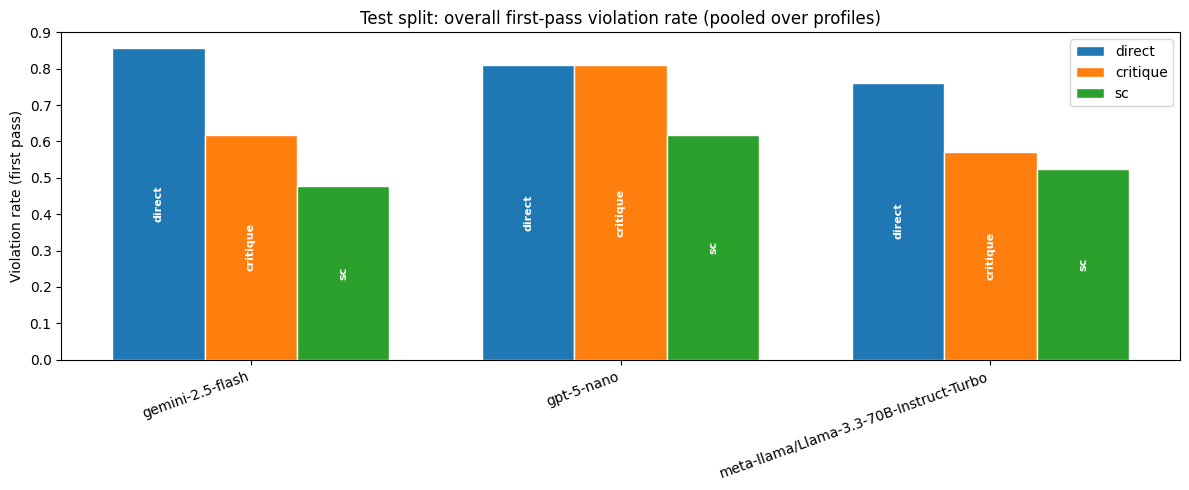

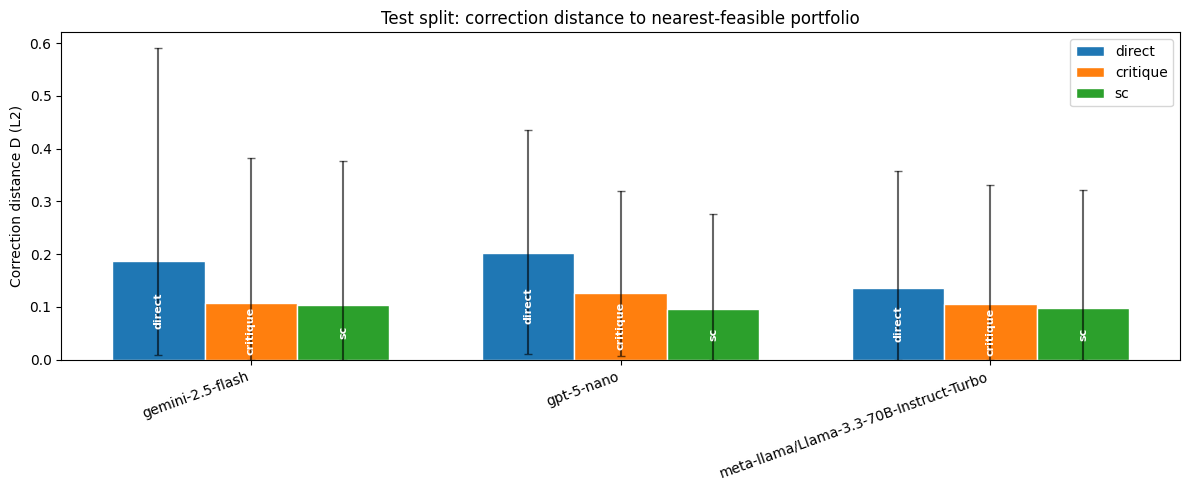

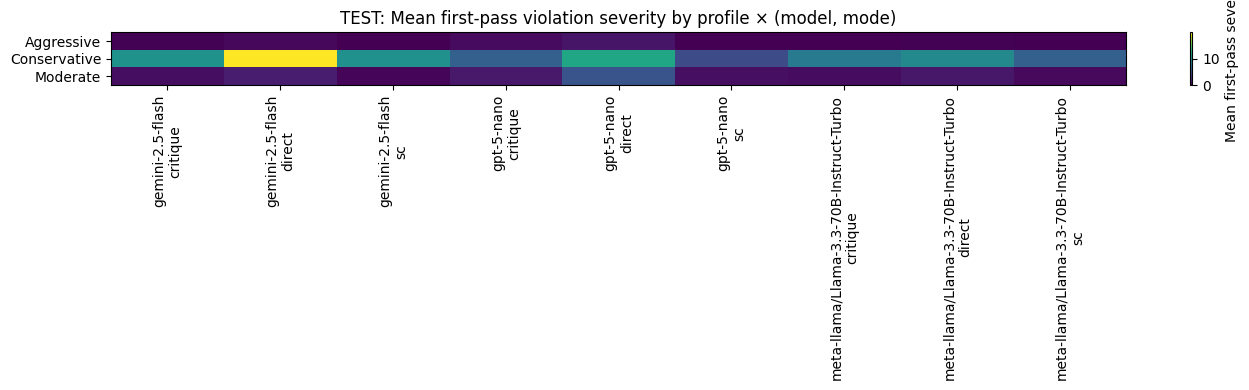

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

VIOL_OVERALL = "/content/tables/violation_overall.csv"
DIST_D = "/content/tables/distance_D_mean_CI.csv"
VIOL_SUMMARY = "/content/tables/violations_summary.csv"

viol = pd.read_csv(VIOL_OVERALL)
dist = pd.read_csv(DIST_D)
vs   = pd.read_csv(VIOL_SUMMARY)

# normalize
for df in (viol, dist, vs):
    df.columns = [c.strip().lower() for c in df.columns]
    df["split"] = df["split"].str.lower()
    df["mode"]  = df["mode"].str.lower()
    df["model"] = df["model"].astype(str)

# Test split violation rate
sub = viol[viol["split"]=="test"].copy()
profiles = sorted(sub["profile"].unique())
modes = ["direct","critique","sc"]
models = sorted(sub["model"].unique())

fig, ax = plt.subplots(figsize=(12,5))
x = np.arange(len(models))
width = 0.25
patterns = ["", "/", "o"]

for j, mode in enumerate(modes):
    tmp = sub[sub["mode"]==mode]
    g = tmp.groupby("model", as_index=False).agg(rate=("rate","mean"))
    y_values = g.set_index("model").loc[models]["rate"].values

    # Calculate positions
    pos = x + (j-1)*width
    bars = ax.bar(pos, y_values, width, label=mode, edgecolor='white')

    for i, v in enumerate(y_values):
        if v > 0.1:
            ax.text(pos[i], v/2, mode, ha='center', va='center',
                    rotation=90, color='white', fontweight='bold', fontsize=8)
        else:
            ax.text(pos[i], v + 0.01, mode, ha='center', va='bottom',
                    rotation=90, fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.set_ylabel("Violation rate (first pass)")
ax.set_title("Test split: overall first-pass violation rate (pooled over profiles)")
ax.legend()
plt.tight_layout()
plt.savefig("violation_rate.pdf", format="pdf", bbox_inches="tight")
plt.show()


# Test split correction distance D
subd = dist[dist["split"]=="test"].copy()
fig, ax = plt.subplots(figsize=(12,5))
x = np.arange(len(models))
width = 0.25

for j, mode in enumerate(modes):
    tmp = subd[subd["mode"]==mode].groupby("model", as_index=False).agg(
        mean=("mean","mean"),
        lo=("ci_lo","min"),
        hi=("ci_hi","max"),
    )
    tmp = tmp.set_index("model").loc[models].reset_index()
    y = tmp["mean"].values
    yerr = np.vstack([y - tmp["lo"].values, tmp["hi"].values - y])

    pos = x + (j-1)*width
    ax.bar(pos, y, width, label=mode, edgecolor='white')
    ax.errorbar(pos, y, yerr=yerr, fmt="none", capsize=3, color='black', alpha=0.6)

    for i, val in enumerate(y):
        if val > 0.05:
            ax.text(pos[i], val/2, mode, ha='center', va='center',
                    rotation=90, color='white', fontweight='bold', fontsize=8)
        else:
            ax.text(pos[i], val + 0.01, mode, ha='center', va='bottom',
                    rotation=90, fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.set_ylabel("Correction distance D (L2)")
ax.set_title("Test split: correction distance to nearest-feasible portfolio")
ax.legend()
plt.tight_layout()
plt.savefig("correction_distance.pdf", format="pdf", bbox_inches="tight")
plt.show()


# Test split mean severity
subvs = vs[vs["split"]=="test"].copy()
pivot = subvs.pivot_table(index="profile", columns=["model","mode"], values="v_severity_mean", aggfunc="mean")
plt.figure(figsize=(14,4))
plt.imshow(pivot.values, aspect="auto", cmap='viridis')
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(len(pivot.columns)), [f"{a}\n{b}" for a,b in pivot.columns], rotation=90)
plt.colorbar(label="Mean first-pass severity")
plt.title("TEST: Mean first-pass violation severity by profile × (model, mode)")
plt.tight_layout()
plt.savefig("violation_severity.pdf", format="pdf", bbox_inches="tight")
plt.show()


print("Downloading PDF files...")
files.download("violation_rate.pdf")
files.download("correction_distance.pdf")
files.download("violation_severity.pdf")

In [ ]:
import json
import pandas as pd
import numpy as np

RESULTS_JL = "/content/results.jsonl"

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows

rows = read_jsonl(RESULTS_JL)
df = pd.json_normalize(rows)

# --- Separate event types
fp = df[df["stage"] == "first_pass"].copy()
fin = df[df["stage"] == "final"].copy()
pf  = df[df["stage"] == "parse_fail"].copy()

if "pass" in fp.columns:
    fp["pass"] = fp["pass"].astype(bool)
if "passes" in fin.columns:
    fin["passes"] = fin["passes"].astype(bool)
if "D" in fin.columns:
    fin["D"] = pd.to_numeric(fin["D"], errors="coerce")


# "Final outcome" key = (scenario, model, mode, split)
#  If final exists => parse ultimately succeeded
key_cols = ["scenario", "model", "mode", "split"]

# Keep one final row per key (if duplicates exist, keep the last)
fin_keyed = (fin.sort_values("ts") if "ts" in fin.columns else fin).drop_duplicates(
    subset=key_cols, keep="last"
)

success_keys = set(tuple(x) for x in fin_keyed[key_cols].to_numpy())

# Parse fails that never produced a final for that key => true parse failure
pf["key"] = list(map(tuple, pf[key_cols].to_numpy()))
pf_true = pf[~pf["key"].isin(success_keys)].copy()


# First-pass violation rate (based on first_pass 'pass')
# De-duplicate first_pass per key (take last/any)
fp_keyed = fp.drop_duplicates(subset=key_cols, keep="last").copy()
fp_keyed["v_any"] = ~fp_keyed["pass"]

# TEST split summary: violation range + pooled
test_fp = fp_keyed[fp_keyed["split"] == "test"].copy()
rate_by_model_mode = (
    test_fp.groupby(["model", "mode"])["v_any"].mean().reset_index(name="v_rate")
)

v_min = float(rate_by_model_mode["v_rate"].min())
v_max = float(rate_by_model_mode["v_rate"].max())
v_pooled = float(test_fp["v_any"].mean())

print("TEST first-pass violation rate range:", v_min, "to", v_max)
print("TEST pooled first-pass violation rate:", v_pooled)


# Correction distance D median (final stage)
D_overall = float(fin_keyed["D"].median())
D_test = float(fin_keyed[fin_keyed["split"] == "test"]["D"].median())

print("Overall pooled median D:", D_overall)
print("TEST pooled median D:", D_test)


# Final feasibility rate (after projection)
final_pass_rate = fin_keyed.groupby("split")["passes"].mean()
print("Final passes rate by split:\n", final_pass_rate)


# True parse-fail rate (after retries)
attempted_keys = len(success_keys) + len(pf_true.drop_duplicates(subset=key_cols))
pf_rate = len(pf_true.drop_duplicates(subset=key_cols)) / attempted_keys if attempted_keys else np.nan
print("Parse-fail rate (after retries):", pf_rate)

pf_counts = (pf_true.drop_duplicates(subset=key_cols)
             .groupby(["split","model","mode"]).size().reset_index(name="parse_fail_final_count"))
print(pf_counts)


TEST first-pass violation rate range: 0.47619047619047616 to 0.8571428571428571
TEST pooled first-pass violation rate: 0.671957671957672
Overall pooled median D: 0.048164959451942366
TEST pooled median D: 0.0669135267793834
Final passes rate by split:
 split
dev      1.0
test     1.0
train    1.0
Name: passes, dtype: float64
Parse-fail rate (after retries): 0.0
Empty DataFrame
Columns: [split, model, mode, parse_fail_final_count]
Index: []


### Sector-level before/after plots (test split, all modes)

Loaded events: 189
Modes present: ['critique', 'direct', 'sc']
Models present: ['gemini-2.5-flash', 'gpt-5-nano', 'meta-llama/Llama-3.3-70B-Instruct-Turbo']


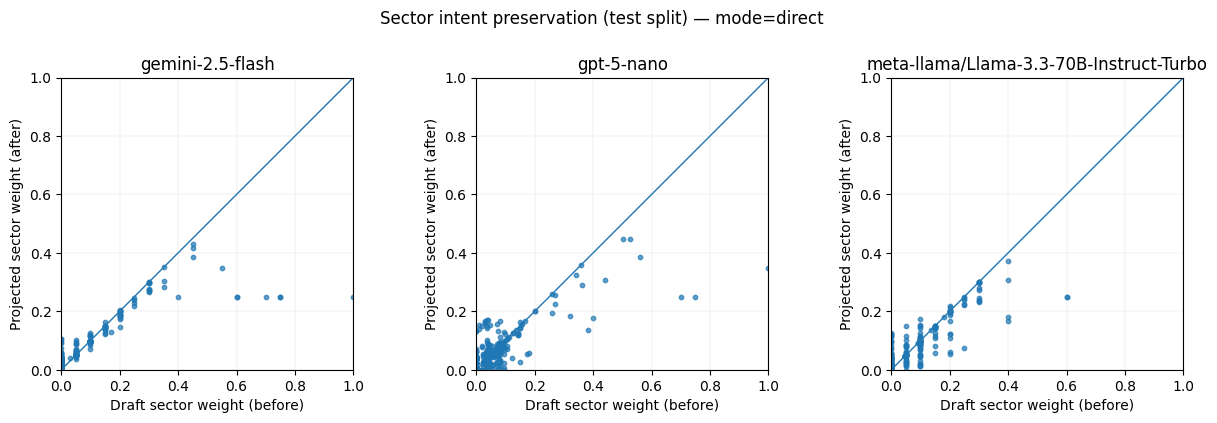

Wrote: /content/figs/fig_sector_before_after_test_direct.pdf


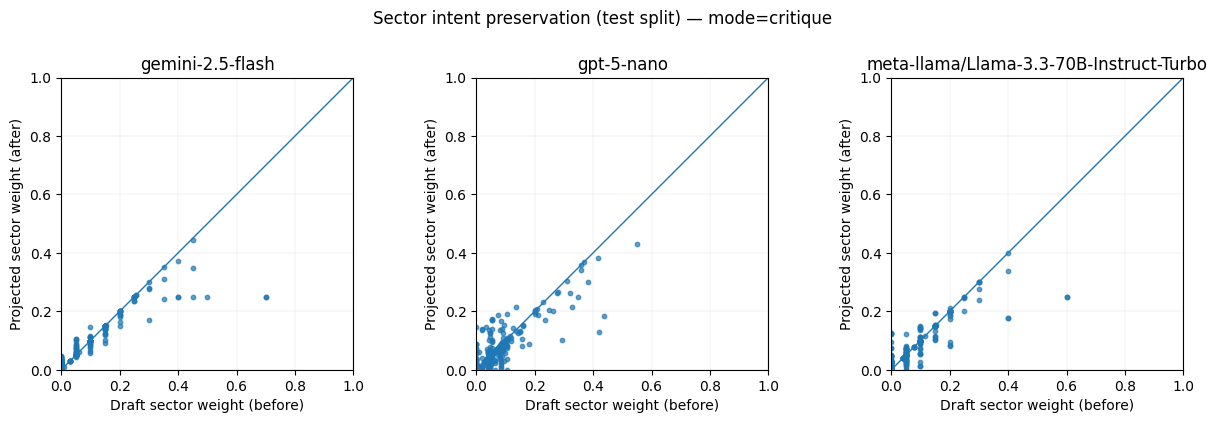

Wrote: /content/figs/fig_sector_before_after_test_critique.pdf


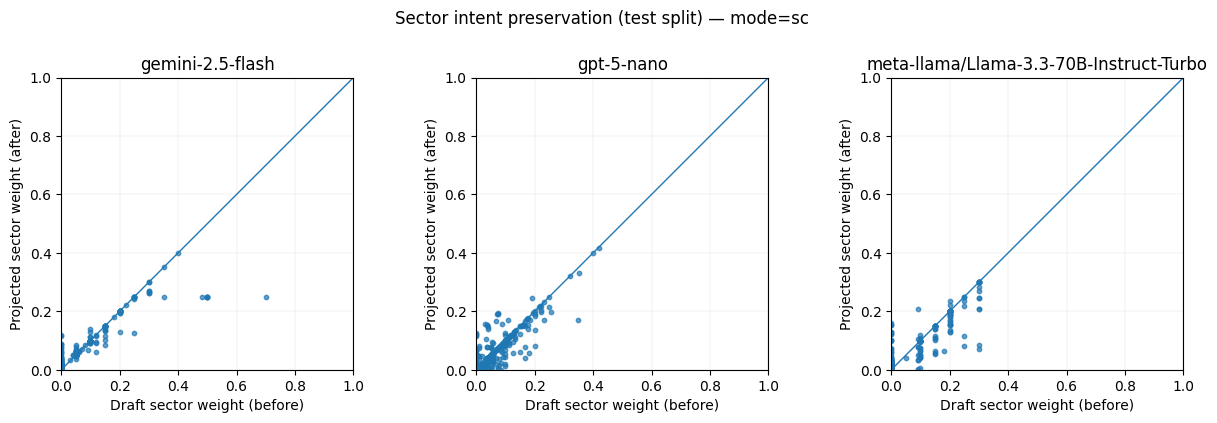

Wrote: /content/figs/fig_sector_before_after_test_sc.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Sector before/after plots

import json
from pathlib import Path
import matplotlib.pyplot as plt

RESULTS_PATH = Path("/content/results.jsonl")
OUTDIR = Path("/content/figs")
OUTDIR.mkdir(parents=True, exist_ok=True)

def load_final_test_events(results_path: Path):
    events = []
    with results_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            r = json.loads(line)

            # Filter to final stage + test split
            if r.get("stage") != "final":
                continue
            if r.get("split") != "test":
                continue

            mb = r.get("metrics_before") or {}
            ma = r.get("metrics_after") or {}
            sb = mb.get("sector_sums")
            sa = ma.get("sector_sums")

            if isinstance(sb, dict) and isinstance(sa, dict):
                events.append(r)
    return events

def collect_points(events, mode: str, model: str):
    xs, ys = [], []
    for e in events:
        if e.get("mode") != mode:
            continue
        if e.get("model") != model:
            continue

        sb = (e.get("metrics_before") or {}).get("sector_sums") or {}
        sa = (e.get("metrics_after") or {}).get("sector_sums") or {}

        # intersection of keys
        for k in sorted(set(sb.keys()) & set(sa.keys())):
            try:
                xs.append(float(sb[k]))
                ys.append(float(sa[k]))
            except Exception:
                pass
    return xs, ys

def plot_mode(events, mode: str, out_path: Path):
    models = sorted({e.get("model") for e in events if e.get("mode") == mode and e.get("model")})
    if not models:
        raise RuntimeError(f"No test/final events found for mode={mode}")

    n = len(models)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4.0), squeeze=False)
    axes = axes[0]

    for ax, model in zip(axes, models):
        xs, ys = collect_points(events, mode=mode, model=model)
        ax.scatter(xs, ys, s=10, alpha=0.7)
        ax.plot([0, 1], [0, 1], linewidth=1)

        ax.set_title(model)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Draft sector weight (before)")
        ax.set_ylabel("Projected sector weight (after)")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, linewidth=0.3, alpha=0.4)

    fig.suptitle(f"Sector intent preservation (test split) — mode={mode}", y=1.02)
    fig.tight_layout()
    fig.savefig(out_path, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

events = load_final_test_events(RESULTS_PATH)
print("Loaded events:", len(events))
print("Modes present:", sorted({e.get("mode") for e in events}))
print("Models present:", sorted({e.get("model") for e in events}))

for mode in ["direct", "critique", "sc"]:
    out_path = OUTDIR / f"fig_sector_before_after_test_{mode}.pdf"
    plot_mode(events, mode, out_path)
    print("Wrote:", out_path)

# download files
from google.colab import files
for mode in ["direct", "critique", "sc"]:
    files.download(str(OUTDIR / f"fig_sector_before_after_test_{mode}.pdf"))


### Solver ablation table on test split

Re-run the projection on held-out test drafts under different solver settings and reports:

*  Solve success rate (solver returned optimal/accurate solution)
*  Final feasible rate (passes all hard caps after validation)





In [ ]:
!pip -q install cvxpy osqp

import json, time
import numpy as np
import pandas as pd
import cvxpy as cp

ASSETS_CSV = "/content/assets.csv"
SIGMA_NPY  = "/content/sigma.npy"
SCENARIOS  = "/content/scenarios_full.jsonl"
RESULTS    = "/content/results.jsonl"

# Load assets / Sigma
assets = pd.read_csv(ASSETS_CSV)

fees = assets["expense_ratio"].to_numpy(dtype=float)
sectors = assets["sector"].to_numpy()

Sigma = np.load(SIGMA_NPY).astype(float)

# Load scenarios into dict
sc_meta = {}
with open(SCENARIOS, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        r = json.loads(line)
        sc_meta[r["scenario_id"]] = r

# Load results
rows = []
with open(RESULTS, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            rows.append(json.loads(line))

# We use FINAL rows and filter to TEST split (all modes)
final_test = [
    r for r in rows
    if str(r.get("stage","")).lower() == "final" and r.get("split") == "test"
]
print("final_test rows:", len(final_test))
print("modes:", sorted(set(r.get("mode") for r in final_test)))

# ====== Helper metrics ======
def portfolio_risk(w, S):
    v = float(w @ S @ w)
    return float(np.sqrt(max(v, 0.0)))

def hhi(w):
    return float(np.sum(np.square(w)))

def max_sector_sum(w, sectors_arr):
    mx = 0.0
    for s in np.unique(sectors_arr):
        mx = max(mx, float(w[sectors_arr == s].sum()))
    return mx

def validate_caps(w, caps, fees, Sigma, sectors, eps=1e-9):
    w = np.asarray(w, float)
    m = {
        "risk": portfolio_risk(w, Sigma),
        "fee":  float(w @ fees),
        "hhi":  hhi(w),
        "max_asset": float(np.max(w)),
        "max_sector": max_sector_sum(w, sectors),
    }
    ok = (
        (m["risk"] <= caps["sigma_cap"] + eps) and
        (m["fee"]  <= caps["fee_cap"]  + eps) and
        (m["hhi"]  <= caps["hhi_cap"]  + eps) and
        (m["max_asset"]  <= caps["max_asset"]  + eps) and
        (m["max_sector"] <= caps["max_sector"] + eps)
    )
    return m, bool(ok)

# Parameterized version of projection same structure)
def project_nearest_feasible_param(
    w_in, caps, fees, Sigma, sectors,
    # numerical safety
    jitter=1e-10,
    # objective reg
    LAMBDA=2e-3,
    # margins/slacks
    tau=2e-3, risk_eps=7e-4, fee_eps=1e-6, hhi_eps=3e-4,
    # solver params
    try_osqp_first=True,
    osqp_eps=1e-7, osqp_max_iter=200000, osqp_polish=True,
    scs_eps=1e-5, scs_max_iters=30000
):
    w0 = np.asarray(w_in, float)
    w0 = np.clip(w0, 0, None)
    s = w0.sum()
    w0 = w0 / s if s > 0 else np.ones_like(w0) / len(w0)

    S = np.asarray(Sigma, float) + jitter * np.eye(Sigma.shape[0])
    sectors = np.asarray(sectors)
    n = len(w0)

    w = cp.Variable(n, nonneg=True)
    obj = cp.Minimize(cp.sum_squares(w - w0) + LAMBDA * cp.quad_form(w, S))

    cons = [
        cp.sum(w) == 1,
        w <= (caps["max_asset"] - tau),
        (fees @ w) <= (caps["fee_cap"] - fee_eps),
        cp.quad_form(w, S) <= (max(caps["sigma_cap"] - risk_eps, 0.0))**2,
        cp.sum_squares(w) <= (caps["hhi_cap"] - hhi_eps),
    ]
    for sname in np.unique(sectors):
        idx = np.where(sectors == sname)[0]
        cons.append(cp.sum(w[idx]) <= (caps["max_sector"] - tau))

    prob = cp.Problem(obj, cons)

    method = None
    status = None

    if try_osqp_first:
        try:
            prob.solve(
                solver=cp.OSQP,
                eps_abs=osqp_eps, eps_rel=osqp_eps,
                max_iter=osqp_max_iter,
                polish=osqp_polish,
                verbose=False,
                warm_start=True,
            )
        except Exception:
            pass

        status = prob.status
        if (w.value is not None) and (status in ("optimal", "optimal_inaccurate")):
            method = "OSQP"

    if method is None:
        try:
            prob.solve(
                solver=cp.SCS,
                eps=scs_eps,
                max_iters=scs_max_iters,
                verbose=False,
                warm_start=True,
            )
        except Exception:
            pass

        status = prob.status
        if (w.value is None) or (status not in ("optimal", "optimal_inaccurate")):
            return {"status": status, "w": None, "method": "FAILED"}

        method = "SCS"

    w_star = np.clip(np.array(w.value).ravel(), 0, None)
    s = w_star.sum()
    w_star = w_star / s if s > 0 else np.ones_like(w_star) / len(w_star)

    return {"status": status, "w": w_star, "method": method}

# ablation settings
ABLATIONS = [
    dict(
        name="Default",
        try_osqp_first=True,
        osqp_eps=1e-7, osqp_max_iter=200000, osqp_polish=True,
        scs_eps=1e-5, scs_max_iters=30000,
        jitter=1e-10,
    ),
    dict(
        name="SCS tighter tol",
        try_osqp_first=False,
        scs_eps=5e-6, scs_max_iters=60000,
        jitter=1e-10,
    ),
    dict(
        name="SCS looser tol",
        try_osqp_first=False,
        scs_eps=2e-5, scs_max_iters=15000,
        jitter=1e-10,
    ),
    dict(
        name="More jitter",
        try_osqp_first=False,
        scs_eps=1e-5, scs_max_iters=30000,
        jitter=1e-8,
    ),
    dict(
        name="No OSQP fast-path",
        try_osqp_first=False,
        scs_eps=1e-5, scs_max_iters=30000,
        jitter=1e-10,
    ),
]

# Run ablations
def run_ablation(setting):
    n = 0
    solve_ok = 0
    feasible_ok = 0
    used_osqp = 0
    Ds = []
    times_ms = []

    for r in final_test:
        sid = r["scenario"]
        caps = sc_meta[sid]["caps"]
        w0 = np.asarray(r["w0"], float)

        t0 = time.perf_counter()
        out = project_nearest_feasible_param(
            w0, caps, fees, Sigma, sectors,
            jitter=setting.get("jitter", 1e-10),
            try_osqp_first=setting.get("try_osqp_first", True),
            osqp_eps=setting.get("osqp_eps", 1e-7),
            osqp_max_iter=setting.get("osqp_max_iter", 200000),
            osqp_polish=setting.get("osqp_polish", True),
            scs_eps=setting.get("scs_eps", 1e-5),
            scs_max_iters=setting.get("scs_max_iters", 30000),
        )
        t1 = time.perf_counter()
        times_ms.append(1000.0 * (t1 - t0))

        n += 1
        if out["w"] is None:
            continue

        solve_ok += 1
        if out["method"] == "OSQP":
            used_osqp += 1

        w_star = out["w"]
        _, ok = validate_caps(w_star, caps, fees, Sigma, sectors)
        feasible_ok += int(ok)

        Ds.append(float(np.linalg.norm(w_star - w0, ord=2)))

    def pct(x): return 100.0 * x / max(n, 1)

    return {
        "Setting": setting["name"],
        "Solve success %": round(pct(solve_ok), 2),
        "Final feasible %": round(pct(feasible_ok), 2),
        "Solved by OSQP %": round(pct(used_osqp), 2),
        "Median D": round(float(np.median(Ds)) if Ds else float("nan"), 4),
        "Mean time (ms)": round(float(np.mean(times_ms)) if times_ms else float("nan"), 2),
        "N": n,
    }

ablation_rows = [run_ablation(s) for s in ABLATIONS]
df = pd.DataFrame(ablation_rows)
df


final_test rows: 189
modes: ['critique', 'direct', 'sc']


,Setting,Solve success %,Final feasible %,Solved by OSQP %,Median D,Mean time (ms),N
0,Default (paper),100.0,100.0,0.0,0.0669,61.32,189
1,SCS tighter tol,100.0,100.0,0.0,0.0669,59.29,189
2,SCS looser tol,100.0,100.0,0.0,0.0669,59.73,189
3,More jitter,100.0,100.0,0.0,0.0669,61.18,189
4,No OSQP fast-path (SCS only),100.0,100.0,0.0,0.0669,58.16,189


In [ ]:
# Save CSV
out_csv = "/content/ablation_solver_table.csv"
df.to_csv(out_csv, index=False)
print("Wrote:", out_csv)


Wrote: /content/ablation_solver_table.csv
Wrote: /content/ablation_solver_table.tex
